# 30_05 — Modelos de referencia · Escenario 1 · FAR(1) lineal gaussiano · **barrido en $M$**

Paso **3c**, posterior a `30_04_evaluacion`. Eje 1 de `§03_06`: el PSBPM-FD
contra los modelos de referencia, sobre la misma representación y con el mismo
conjunto de información. Sólo métricas **puntuales**.

| Modelo | Qué es | Referencia |
|---|---|---|
| `FAR` | $\hat\rho$ como **operador sobre la curva**, truncamiento espectral en $k_n$ | Bosq (2000); `far::far()` de Damon & Guillas |
| `RF` | bosque aleatorio multisalida | no lineal |
| `GBT` | *gradient boosting* por score | no lineal |
| `media`, `persistencia` | líneas base de `fit/baselines.py` | piso |

Control: FAR(1) lineal, gaussiano y homogéneo. El `FAR` está **correctamente
especificado** en este escenario, de modo que empatar con él o quedar algo por
detrás es lo esperado, y esa brecha es la cota con la que se leen los demás
escenarios. `RF` y `GBT` deberían perder.

## Qué cambió respecto de versiones anteriores de este notebook

Hasta ahora había **dos** referencias lineales, `VAR` y `FAR1`, y no eran dos:
`ajustar_far1` calculaba $\hat\Psi=\hat C_1\hat C_0^{-1}$ con momentos **sin
centrar** sobre los mismos $M$ scores, es decir MCO sin intercepto; y como los
scores ya vienen centrados en el bloque de entrenamiento, coincidía con el VAR
hasta `corr = 1.00000000` con $M=1$. Se dibujaban una encima de la otra y el
notebook tenía una lógica entera dedicada a detectarlo y esconder una de las
dos.

Ambas se retiraron y en su lugar va **un solo** competidor lineal: el estimador
de Bosq tal como lo implementa `far::far()` del paquete `far` de R, ahora en
`fit/far_operador.py`. La diferencia no está en la fórmula $\hat C_1\hat
C_0^{-1}$ sino en **dónde vive y cómo se regulariza**: opera sobre la curva en
la grilla, estima su propia base propia y trunca en $k_n$ elegido por error de
**predicción**, no por varianza explicada. Su $k_n$ es independiente de $M$, y
eso es justamente lo que lo separa del VAR: medido en esta corrida, entre 79 %
y 106 % de la desviación típica del ajuste, contra el 0.04–1.1 % del estimador
anterior.

**Consecuencia para el resto del notebook:** el normalizador de la §8 pasa de
`MISE_rel_VAR` a `MISE_rel_FAR`.

## Por qué el barrido cambia lo que este notebook puede concluir

Con un solo $M$, que el PSBPM-FD quede por detrás del VAR admite dos lecturas
que no se distinguen: *el modelo es peor* o *la representación no le da con qué
ganar*. El barrido las separa, porque **todos los competidores viven sobre la
misma representación**: si al subir $M$ se degradan todos por igual, el
responsable es el truncamiento FPCA y no el modelo; si sólo se degrada el
PSBPM-FD, la hipótesis de la Etapa D —$M$ entra dos veces, y la segunda diluye
el prior de selección de los pesos de la mezcla— queda respaldada.

Ésa es la comparación de la **§8**, y es la razón de ser de esta versión del
notebook.

## 1. Imports, rutas y artefactos

In [1]:
import sys
import json as _json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import PSBPPredictor
from model_psbp_fd.fit import (
    rmse_por_coeficiente, r2_por_columna, razon_dispersion,
    mise, rmse_funcional, ventana_movil_funcional,
    # Bloque A: las tres normas del mismo error, para TODOS los modelos
    resumen_error_funcional, normas_error_por_origen, pesos_normalizados,
    # incertidumbre bajo dependencia entre orígenes
    bootstrap_bloques, largo_bloque_sugerido,
    # Bloque B: intervalo implicado por el modelo, y sus métricas
    residuos_para_banda, banda_predictiva_modelo, sigma_residual,
    resumen_intervalo, winkler, indicador_cobertura,
)
from model_psbp_fd.graphics import plot_ventana_movil
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# == [CONFIG] ================================================================
# BARRIDO EN M. Debe ser el mismo que en 30_01, 30_03, 30_04 y el .m.
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario", 1, 1
M_FPCA_LIST = (1, 2, 3)

# -- Jerarquia de metricas. SE FIJA AQUI, ANTES DE VER NINGUN RESULTADO -----
# Debe coincidir con la declarada en 30_04: si los dos notebooks rankearan por
# metricas distintas, la comparacion del PSBPM-FD con sus referencias no seria
# la misma comparacion que la del barrido en M.
#
#   Bloque A  primaria "rmse_f" (media condicional, el funcional que estima el
#             PSBPM-FD y el que usa el MISE del resto del capitulo) o "mae_f"
#             (mediana condicional, robusta). NO las dos: con predictivas
#             asimetricas pueden ordenar los modelos al reves.
#   Bloque B  no aplica a los competidores; ver la seccion 7.2.
METRICA_PRIMARIA_A = "rmse_f"      # {"rmse_f", "mae_f"}
DIAGNOSTICAS_A = ["mae_f", "linf_medio", "linf_max", "q95_abs_medio",
                  "razon_linf_l1_media", "l2_medio", "razon_agregacion"]

Q_EXTREMO = 0.95    # cuantil de |e| que sustituye al supremo como cifra citable
PESOS_TAU = None    # ponderacion del DOMINIO tau; None = uniforme. La MISMA
                    # para todos los modelos, o la comparacion no seria justa.

BOOT_B      = 2000
BOOT_SEED   = 20260905
BOOT_BLOQUE = None   # None -> largo_bloque_sugerido; se reporta el usado

# -- Bloque B: como se construye el intervalo de los competidores -----------
# El FAR de Bosq NO es un algoritmo de prediccion puntual: es un modelo,
# X_{t+1} = rho(X_t) + eps, de modo que su intervalo a un paso es el clasico
# del AR --centro en la prediccion, dispersion la de la innovacion estimada--
# y sale del propio metodo, no de un procedimiento adosado.
NIVEL_IC   = 0.95    # debe coincidir con el `nivel_credibilidad` del _04
IC_POR_TAU = True    # sigma_eps(tau) punto a punto: la banda hereda la forma
                     # de la innovacion funcional. False = ancho constante.
IC_CORRECCION_ESTIMACION = True   # infla sigma por sqrt(1 + kn/n_train), la
                     # correccion de primer orden por rho estimado y no conocido

# Al PSBPM-FD se le construye la MISMA banda ademas de la suya bayesiana, de
# modo que la tabla tenga tres filas y se pueda separar "gana por el modelo" de
# "gana por el mecanismo de intervalo". Sin esa fila, la comparacion mezcla las
# dos cosas y no hay forma de saber cual manda.
IC_PSBP_TAMBIEN_GAUSSIANA = True
# ============================================================================

M_FPCA_LIST = tuple(int(m) for m in M_FPCA_LIST)
EXPERIMENT_BASE = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"


def experiment_id(M: int) -> str:
    return f"{EXPERIMENT_BASE}_m{M:02d}"


def rutas(M: int) -> dict:
    eid = experiment_id(M)
    p = {
        "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / eid,
        "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / eid,
        "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / eid,
        "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / eid,
        "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / eid,
    }
    for r in p.values():
        r.mkdir(parents=True, exist_ok=True)
    return p


PATHS_M      = {M: rutas(M) for M in M_FPCA_LIST}
PATH_BARRIDO = PROJECT_ROOT / "reports" / "simulaciones" / f"{EXPERIMENT_BASE}_barrido_M"
PATH_BARRIDO.mkdir(parents=True, exist_ok=True)

# Este notebook NO pisa nada de 30_04: los _04 ocupan 50-65 según el escenario,
# éste escribe 70-75 en cada directorio de M, y 90-93 en el del barrido.
PREFIJO = 70

print(f"barrido en M : {list(M_FPCA_LIST)}")
for M in M_FPCA_LIST:
    print(f"  M={M}  ->  {experiment_id(M)}   (archivos {PREFIJO}-{PREFIJO+5})")
print(f"salidas cruzadas (§8) : {PATH_BARRIDO}   (archivos 90-93)")

barrido en M : [1, 2, 3]
  M=1  ->  escenario_1_r01_m01   (archivos 70-75)
  M=2  ->  escenario_1_r01_m02   (archivos 70-75)
  M=3  ->  escenario_1_r01_m03   (archivos 70-75)
salidas cruzadas (§8) : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_barrido_M   (archivos 90-93)


In [3]:
EST, saltados = {}, []

for M in M_FPCA_LIST:
    P = PATHS_M[M]
    if not (P["functional"] / "datasets_manifest.json").exists():
        saltados.append((M, "sin datasets_manifest.json - falta correr 30_01"))
        continue

    dfs_train, manifest = cargar_datasets_ar(P, bloque="train")
    dfs_test,  _        = cargar_datasets_ar(P, bloque="test")
    hp_json     = cargar_hiperparametros(P)
    eval_config = cargar_config_evaluacion(P)

    component_idx = manifest["component_idx"]
    n_components  = len(component_idx)
    assert n_components == M, (
        f"{experiment_id(M)} declara M={M} pero su manifest tiene "
        f"{n_components} componentes.")
    assert manifest["scores_scale"] == "standardized_zscore_ddof0"

    objetivo = eval_config.get("objetivo_evaluacion", "curva_verdadera")
    assert objetivo == "curva_verdadera", (
        f"[M={M}] objetivo_evaluacion={objetivo!r}. Este notebook compara "
        "contra la curva verdadera; con otro objetivo las cifras no serían "
        "las del _04.")

    EST[M] = {
        "paths": P, "eid": experiment_id(M),
        "dfs_train": dfs_train, "dfs_test": dfs_test, "manifest": manifest,
        "hp_json": hp_json, "eval_config": eval_config,
        "component_idx": component_idx, "n_components": n_components,
        "cov_names": list(manifest["cov_names"]),
        "n_lags": int(manifest["n_lags"]),
        "T": int(manifest["T"]), "T0": int(manifest["T0"]),
        "n_iter": int(hp_json["n_iter"]),
        "mcmc_cfg": hp_json["mcmc_config"],
        "objetivo": objetivo,
        "modo_residuo": eval_config.get("modo_residuo", "ninguno"),
        "ventanas_w": list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40])),
    }

assert EST, "Ningún punto del barrido tiene datos. Ejecuta 30_01 primero."
for M, motivo in saltados:
    print(f"! M={M} saltado: {motivo}")

_comun = {M: (e["T"], e["T0"], e["n_lags"], e["objetivo"], e["modo_residuo"],
              tuple(e["ventanas_w"])) for M, e in EST.items()}
if len(set(_comun.values())) > 1:
    for M, v in _comun.items():
        print(f"  M={M}: {v}")
    raise AssertionError(
        "El barrido exige T, T0, n_lags, objetivo, modo_residuo y ventanas "
        "idénticos entre puntos.")

_M0        = next(iter(EST))
T          = EST[_M0]["T"]
T0         = EST[_M0]["T0"]
N_LAGS     = EST[_M0]["n_lags"]
OBJETIVO   = EST[_M0]["objetivo"]
MODO_RESIDUO = EST[_M0]["modo_residuo"]
VENTANAS_W = EST[_M0]["ventanas_w"]
W_COMP     = VENTANAS_W[len(VENTANAS_W) // 2]

print(f"\nT={T}  T0={T0}  n_lags={N_LAGS}  objetivo={OBJETIVO!r}  "
      f"modo_residuo={MODO_RESIDUO!r}")
print(f"anchos de ventana: {VENTANAS_W}   ·   referencia para las tablas: w={W_COMP}")
for M, e in EST.items():
    print(f"  M={M}: {e['n_components']} componentes · "
          f"{len(e['cov_names'])} covariables {e['cov_names']}")


T=800  T0=560  n_lags=1  objetivo='curva_verdadera'  modo_residuo='ninguno'
anchos de ventana: [10, 20, 40]   ·   referencia para las tablas: w=20
  M=1: 1 componentes · 1 covariables ['fpc_1_lag1']
  M=2: 2 componentes · 2 covariables ['fpc_1_lag1', 'fpc_2_lag1']
  M=3: 3 componentes · 3 covariables ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1']


In [4]:
for M in EST:
    e, P = EST[M], EST[M]["paths"]

    fpca = cargar_fpca(P)
    _ver = fpca.verificar()
    assert _ver["todo_ok"], f"[M={M}] las identidades FPCA no se cumplen: {_ver}"

    std = cargar_estandarizador(P, DataStandardizer)
    X_obs, grilla = cargar_curvas(P)         # (T, G) con ruido de medición
    X_true        = cargar_curvas_true(P)    # (T, G) verdadera - el objetivo

    assert e["component_idx"] == list(range(fpca.M)), (
        "La reconstrucción funcional necesita el vector completo de scores en "
        f"orden; [M={M}] COMPONENT_IDX={e['component_idx']} y M={fpca.M}.")
    assert std.n_ajuste == T0, (
        f"[M={M}] el estandarizador se ajustó con n={std.n_ajuste} y T0={T0}: "
        "habría fuga del bloque de prueba.")

    e.update({"fpca": fpca, "std": std, "X_obs": X_obs, "X_true": X_true,
              "grilla": grilla, "M_fpca": fpca.M, "K": fpca.K,
              "SCORES": fpca.SCORES,
              "SCORES_STD": std.transform(fpca.SCORES),
              "var_explicada": float(fpca.meta["var_explained"])})
    print(f"M={M}  FPCA M={fpca.M} K={fpca.K}  ·  varianza explicada por las M "
          f"retenidas: {e['var_explicada']:.4%}")

for M in EST:
    assert np.allclose(EST[M]["X_true"], EST[_M0]["X_true"]), (
        f"[M={M}] las curvas verdaderas difieren de las de M={_M0}.")
grilla = EST[_M0]["grilla"]
X_true = EST[_M0]["X_true"]
print(f"\nOK los {len(EST)} puntos salen de la MISMA simulación: curvas "
      f"{X_true.shape}, grilla {grilla.shape}")

M=1  FPCA M=1 K=4  ·  varianza explicada por las M retenidas: 82.9797%
M=2  FPCA M=2 K=4  ·  varianza explicada por las M retenidas: 97.6881%
M=3  FPCA M=3 K=4  ·  varianza explicada por las M retenidas: 99.7883%

OK los 3 puntos salen de la MISMA simulación: curvas (800, 100), grilla (100,)


## 2. Serie de orígenes y matriz de diseño

In [5]:
# La serie de orígenes es común: T, T0 y n_lags no dependen de M.
t_orig   = np.arange(N_LAGS + 1, T + 1)      # tiempo del experimento, base-1
n_orig   = len(t_orig)
T0_orig  = T0 - N_LAGS                        # corte en el indexado de orígenes
es_train = t_orig <= T0
X_true_ev = X_true[N_LAGS:]                   # (n_orig, G) VERDADERA

print(f"orígenes evaluados : {n_orig}  (train {es_train.sum()} · "
      f"test {(~es_train).sum()})")
print(f"corte T0={T0}  ->  índice de origen T0_orig={T0_orig}")

for M in EST:
    e = EST[M]
    dfs_full = {k: pd.concat([e["dfs_train"][k], e["dfs_test"][k]],
                             ignore_index=True) for k in range(e["n_components"])}
    assert len(dfs_full[0]) == n_orig, f"[M={M}] {len(dfs_full[0])} != {n_orig}"

    # Objetivo (n_orig, M) en escala estandarizada, y matriz de diseño común.
    Y_obs = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy(dtype=float)
                             for k in range(e["n_components"])])

    cols0 = list(dfs_full[0].columns[1:])
    for k in range(1, e["n_components"]):
        assert list(dfs_full[k].columns[1:]) == cols0, (
            f"[M={M}] la componente k={k} usa covariables distintas de la k=0; "
            "la matriz de diseño común deja de ser válida.")
    assert cols0 == e["cov_names"], (
        f"[M={M}] las columnas del dataset {cols0} no son cov_names "
        f"{e['cov_names']}.")

    Z = np.asarray(dfs_full[0].iloc[:, 1:], dtype=float)      # (n_orig, p)
    e.update({"dfs_full": dfs_full, "Y_obs": Y_obs, "Z": Z, "p_dis": Z.shape[1]})
    print(f"  M={M}: diseño Z {Z.shape}   objetivo Y {Y_obs.shape}")

orígenes evaluados : 799  (train 559 · test 240)
corte T0=560  ->  índice de origen T0_orig=559
  M=1: diseño Z (799, 1)   objetivo Y (799, 1)
  M=2: diseño Z (799, 2)   objetivo Y (799, 2)
  M=3: diseño Z (799, 3)   objetivo Y (799, 3)


In [6]:
# Curvas de referencia y el piso de la representación, por M.
def hacer_curvas_desde_scores_std(M):
    """Devuelve el mapa scores estandarizados -> curvas en la grilla, para M.

    Es el mapa determinista de `PropagadorFuncional` con modo_residuo="ninguno":
    des-estandarizar y reconstruir. Se escribe así y no se instancia el
    propagador porque éste devuelve extracciones de una predictiva y aquí sólo
    hay una media condicional.
    """
    e = EST[M]

    def _f(Y_std_pred):
        S = e["std"].inverse_transform(np.atleast_2d(Y_std_pred))
        return e["fpca"].reconstruct(S)

    return _f


for M in EST:
    e = EST[M]
    f = hacer_curvas_desde_scores_std(M)
    e["curvas_desde_scores_std"] = f
    e["X_proj"] = e["fpca"].reconstruct(e["SCORES"])[N_LAGS:]

    # Control: reconstruir el objetivo observado debe dar exactamente X_proj.
    assert np.allclose(f(e["Y_obs"]), e["X_proj"], atol=1e-8), (
        f"[M={M}] el mapa scores->curva no reproduce la proyección FPCA; "
        "revisar el estandarizador cargado.")

    e["MISE_TRUNC"] = {b: mise(X_true_ev[m], e["X_proj"][m], grilla)
                       for b, m in (("train", es_train), ("test", ~es_train))}

print("MISE del TRUNCAMIENTO FPCA (piso común a todos los modelos de cada M):")
print(f"{'M':>3}  {'train':>11}  {'test':>11}")
for M in EST:
    v = EST[M]["MISE_TRUNC"]
    print(f"{M:>3}  {v['train']:>11.6f}  {v['test']:>11.6f}")
print("  <- ningún modelo sobre esa representación puede bajar de ahí")

MISE del TRUNCAMIENTO FPCA (piso común a todos los modelos de cada M):
  M        train         test
  1     0.251333     0.228561
  2     0.035136     0.034991
  3     0.005494     0.005754
  <- ningún modelo sobre esa representación puede bajar de ahí


## 3. Los competidores

Cada uno se ajusta **sólo con los orígenes de entrenamiento** y devuelve
`(n_orig, M)` predicciones a $h=1$ en escala estandarizada. Los
hiperparámetros son **idénticos entre escenarios y entre puntos del barrido**:
si se ajustaran por $M$, la comparación dejaría de aislar el efecto de $M$.

### 3.1 FAR(1) como operador sobre la curva — Bosq (2000), vía `far::far()`

Única referencia lineal del estudio. `fit/far_operador.py` reproduce el
comportamiento efectivo de `far::far()` del paquete `far` 0.6-7 de R (Damon &
Guillas), verificado contra su salida hasta **5e-16** (`tests/test_far_operador.py`).

El estimador, con una sola variable:

$$\hat\rho = \hat C_1 \hat C_0^{-1} \quad\text{restringido a }
\operatorname{span}(v_1,\dots,v_{k_n}),$$

donde los $v_j$ son los autovectores de $\hat C_0$. La regularización es el
**truncamiento espectral en $k_n$**, aplicado por los dos lados, más una
pseudo-inversa de Moore-Penrose como red de seguridad.

#### $k_n$ NO es $M$, y la distinción es la razón de ser de esta sección

- $M$ sale de la **regla del 95 %** de varianza acumulada del FPCA y dice
  cuánto de la curva se conserva.
- $k_n$ regulariza la inversión de $\hat C_0$, que es un operador **no
  acotado**: lo que hay que controlar no es cuánta varianza se pierde sino
  cuánto se amplifica el error de estimación en las direcciones de autovalor
  pequeño. Una componente puede aportar poca varianza y mucha predicción.

Por eso $k_n$ se elige por **error de predicción a un paso** (la celda
siguiente), replicando `far.cv`. Confundir los dos criterios sería meter la
regla del 95 % donde el problema es de mal planteamiento y no de
representación.

#### Sobre la curva, no sobre los scores

El FAR se ajusta con las curvas del bloque de entrenamiento y predice en la
grilla; recién después su predicción se proyecta sobre las $M$ autofunciones y
se estandariza, para que entre en la misma tabla que los demás. El conjunto de
información es el mismo —la curva en $t-1$— pero **su base propia no es la del
FPCA del pipeline**, y ahí está toda la diferencia metodológica.

In [7]:
from model_psbp_fd.fit.far_operador import (
    FAR1, seleccionar_kn, comparar_con_ajustar_far1)

# [CONFIG] Tope del barrido de kn en la validacion. El criterio es plano en
# esta clase de escenarios, de modo que subirlo mucho no cambia el elegido y
# si encarece la busqueda. KN_MAX <= min(L, n_ajuste).
KN_MAX = 12

# [CONFIG] estructura declarada del generador de este escenario, contra la
# que se contrasta la norma estimada. Es lo unico de esta seccion que cambia
# entre escenarios.
HS_REFERENCIA = "0.70"

# [CONFIG] Criterio de far.cv con que se elige kn. "L2" es el unico coherente
# con el MISE que reporta el resto del capitulo; "Linf" pesa el error en el
# pico y suele elegir kn mas chico.
CRITERIO_KN = "L2"

# kn se elige UNA sola vez, con las curvas de entrenamiento, y es el MISMO en
# todos los puntos del barrido: las curvas no dependen de M -M solo cambia la
# representacion posterior-, de modo que reelegirlo por M meteria una
# diferencia de ajuste donde el barrido quiere aislar el efecto de M.
_X_train_far = EST[_M0]["X_obs"][:T0]
CV_KN = seleccionar_kn(_X_train_far, kn_max=KN_MAX, grilla=grilla)
KN_ELEGIDO = {"L1": CV_KN.kn_L1, "L2": CV_KN.kn_L2,
              "Linf": CV_KN.kn_Linf}[CRITERIO_KN]

print(f"far.cv: hold-out de las ultimas {CV_KN.n_validacion} curvas de train")
print(f"{'kn':>4}  " + "  ".join(f"{c:>9}" for c in CV_KN.columnas[1:]))
for fila in CV_KN.tabla:
    marca = "  <-" if int(fila[0]) == KN_ELEGIDO else ""
    print(f"{int(fila[0]):>4}  " + "  ".join(f"{v:>9.4f}" for v in fila[1:])
          + marca)
print(f"\nkn elegido por {CRITERIO_KN}: {KN_ELEGIDO}"
      f"   (L1 -> {CV_KN.kn_L1}, Linf -> {CV_KN.kn_Linf})")

# AVISO. `far.cv` NO es validacion cruzada por particiones: es un hold-out del
# bloque final, de modo que el criterio se estima sobre UN solo bloque y es
# ruidoso. Si el minimo es plano -diferencias por debajo del 1% entre kn
# vecinos- la eleccion no es informativa y hay que reportar la tabla entera,
# no el argmin.
_l2 = CV_KN.tabla[:, 2]
_planitud = float((_l2.max() - _l2.min()) / _l2.min())
print(f"amplitud relativa del criterio {CRITERIO_KN}: {_planitud:.2%}"
      + ("   <- PLANO: la eleccion de kn no es informativa, reportar la tabla"
         if _planitud < 0.05 else ""))


far.cv: hold-out de las ultimas 112 curvas de train
  kn         L1         L2       Linf      L1max      L2max    Linfmax
   1     0.7998     0.9001     1.7203     0.8767     1.0849     3.0948  <-
   2     0.8020     0.9041     1.7429     0.8806     1.0937     3.0729
   3     0.8001     0.9010     1.7314     0.8786     1.0904     3.0715
   4     0.8008     0.9015     1.7242     0.8808     1.0922     3.0624
   5     0.8042     0.9049     1.7271     0.8851     1.0970     3.0805
   6     0.8025     0.9034     1.7249     0.8825     1.0958     3.0323
   7     0.8047     0.9055     1.7265     0.8822     1.0971     3.0012
   8     0.8047     0.9054     1.7260     0.8813     1.0963     3.0121
   9     0.8035     0.9036     1.7223     0.8817     1.0965     3.0002
  10     0.8037     0.9034     1.7207     0.8792     1.0924     3.0547
  11     0.8040     0.9038     1.7217     0.8788     1.0921     3.0540
  12     0.8060     0.9066     1.7262     0.8792     1.0923     3.0583

kn elegido por L2: 1

In [8]:
# El ajuste del FAR y su paso a la escala de los scores. El operador se estima
# UNA vez -no depende de M- y lo que cambia por punto del barrido es solo la
# proyeccion de su prediccion sobre las M autofunciones.
FAR_MOD = FAR1(kn=KN_ELEGIDO, grilla=grilla).fit(_X_train_far)

_diag = FAR_MOD.diagnostico_kn()
print("operador estimado:")
for k, v in _diag.items():
    print(f"  {k:22s}: {v}")
print()
print("`condicion` = lambda_1 / lambda_kn es por lo que se esta dividiendo en la")
print("direccion mas debil retenida: es la cifra que anticipa la sensibilidad a")
print("kn antes de que se vea en el error.")

# Curvas rezagadas de cada origen: el origen t (base-1, t = N_LAGS+1..T) tiene
# como predictor la curva t-1, es decir el indice base-0 t-2.
_X_lag = EST[_M0]["X_obs"][N_LAGS - 1:T - 1]
assert _X_lag.shape[0] == n_orig, (_X_lag.shape, n_orig)
X_pred_far = FAR_MOD.predict(_X_lag)              # (n_orig, G) en la grilla

# La representacion en base se carga aqui y no en el bloque de artefactos
# porque el FAR es el unico competidor que la necesita: es el unico cuya
# prediccion nace en la GRILLA y tiene que recorrer base -> FPCA ->
# estandarizador para entrar en el contrato (n_orig, M) de los demas.
from model_psbp_fd.pipelines import cargar_representacion

for M in EST:
    e = EST[M]
    e["fr"], _THETA_M, _ = cargar_representacion(e["paths"])
    e["PRED"] = {}      # {nombre: (n_orig, M) en escala estandarizada}
    e["INFO"] = {}      # notas por modelo, para el resumen

    # De la grilla a la escala del contrato: base -> FPCA -> estandarizador.
    # Es el camino inverso de `curvas_desde_scores_std`, y por eso el FAR es
    # el unico competidor cuya prediccion NACE en la grilla.
    e["PRED"]["FAR"] = e["std"].transform(
        e["fpca"].transform(e["fr"].transform(X_pred_far)))
    e["INFO"]["FAR"] = (f"kn={KN_ELEGIDO} (por far.cv/{CRITERIO_KN}), "
                        f"||rho||_HS={_diag['norma_hs']:.4f}")

    e["far_hs"]   = float(_diag["norma_hs"])
    e["far_cond"] = float(_diag["condicion"])
    e["far_kn"]   = int(KN_ELEGIDO)

    print(f"M={M}: FAR proyectado -> {e['PRED']['FAR'].shape}")


operador estimado:
  kn                    : 1
  lambda_1              : 1.2272305462379296
  lambda_min_retenido   : 1.2272305462379296
  condicion             : 1.0
  varianza_retenida     : 0.7970667096229902
  norma_hs              : 0.6453810675227513
  n_curvas              : 560
  n_pares               : 559

`condicion` = lambda_1 / lambda_kn es por lo que se esta dividiendo en la
direccion mas debil retenida: es la cifra que anticipa la sensibilidad a
kn antes de que se vea en el error.
M=1: FAR proyectado -> (799, 1)
M=2: FAR proyectado -> (799, 2)
M=3: FAR proyectado -> (799, 3)


#### La $k_n$ que mejor predice NO es la que mejor estima el operador

La celda siguiente lo mide, y es el resultado metodológico propio de esta
sección. Al recorrer $k_n$ se ve que $\|\hat
ho\|_{HS}$ se acerca al valor
del generador y luego **explota**, mientras el error de predicción se queda
plano. No es un defecto de la implementación: es la firma del problema mal
planteado. $\hat C_0^{-1}$ no está acotado, de modo que las direcciones de
autovalor pequeño entran divididas por un número cercano a cero; predecir es un
funcional **mucho más suave** del operador que el operador mismo, y por eso
tolera una $k_n$ que la estimación de $
ho$ no tolera.

**Consecuencia para el reporte, y hay que respetarla:** la $k_n$ elegida por
`far.cv` es la correcta para la fila del FAR en las tablas de MISE, que es
predicción. Pero $\|\hat
ho\|_{HS}$ con esa misma $k_n$ **no debe citarse
como estimación de la norma del generador**: con el $k_n$ predictivo puede
estar un orden de magnitud por encima del 0.70 verdadero, y quien lea la cifra
sin este contexto concluirá que el estimador falla cuando lo que ve es la
regularización. Se reporta la **curva completa** $\|\hat
ho\|_{HS}$ contra
$k_n$, y el $k_n$ donde se estabiliza.

 kn   ||rho||_HS   (curva verd.)   condicion   lambda_kn   L2 pred.
  1       0.6454          0.6455         1.0     1.22723     0.9001   <- kn de far.cv
  2       0.7170          0.7159         5.6     0.21767     0.9041
  3       0.7388          0.7350        38.9     0.03153     0.9010
  4       0.8349          0.8378       375.8     0.00327     0.9015
  5       1.1753          1.2056      1006.3     0.00122     0.9049
  6       1.5718         12.4587      1044.4     0.00118     0.9034
  7       1.6304         49.7551      1075.4     0.00114     0.9055
  8       1.6417         49.7551      1107.5     0.00111     0.9054
  9       1.8703         49.7551      1126.4     0.00109     0.9036
 10       3.2477         49.7551      1142.8     0.00107     0.9034
 11       3.4292         49.7551      1154.5     0.00106     0.9038
 12       3.5269         49.7551      1180.8     0.00104     0.9066

kn de PREDICCION (far.cv/L2): 1  ->  ||rho||_HS = 0.6454
kn de ESTIMACION DEL OPERADOR:          

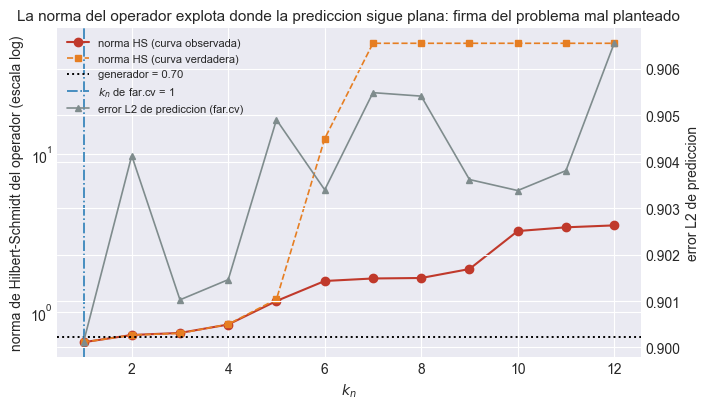

In [9]:
# La norma del operador a lo largo de kn, contra el valor del generador. Con
# la curva VERDADERA ademas de la observada: si la explosion fuera ruido de
# medicion desapareceria al quitarlo, y no desaparece -empeora-, porque las
# curvas verdaderas son mas suaves, su espectro decae antes y lambda_kn es aun
# menor. Eso descarta "es el ruido" y confirma "es C0^-1".
_hs_kn = []
for _kn in range(1, KN_MAX + 1):
    _a = FAR1(kn=_kn, grilla=grilla).fit(_X_train_far)
    _b = FAR1(kn=_kn, grilla=grilla).fit(EST[_M0]["X_true"][:T0])
    _d = _a.diagnostico_kn()
    _hs_kn.append({"kn": _kn, "hs_observada": _a.norma_hs(),
                   "hs_curva_verdadera": _b.norma_hs(),
                   "condicion": _d["condicion"],
                   "lambda_kn": _d["lambda_min_retenido"],
                   "L2_prediccion": float(CV_KN.tabla[_kn - 1, 2])})
hs_kn_df = pd.DataFrame(_hs_kn).set_index("kn")
hs_kn_df.to_csv(PATH_BARRIDO / "94_norma_operador_vs_kn.csv")

print(f"{'kn':>3}  {'||rho||_HS':>11}  {'(curva verd.)':>14}  {'condicion':>10}"
      f"  {'lambda_kn':>10}  {'L2 pred.':>9}")
for _kn, _r in hs_kn_df.iterrows():
    print(f"{_kn:>3}  {_r['hs_observada']:>11.4f}  "
          f"{_r['hs_curva_verdadera']:>14.4f}  {_r['condicion']:>10.1f}  "
          f"{_r['lambda_kn']:>10.5f}  {_r['L2_prediccion']:>9.4f}"
          + ("   <- kn de far.cv" if _kn == KN_ELEGIDO else ""))

# El kn mas grande cuya norma sigue siendo compatible con un operador
# contractivo. NO se usa para predecir: es la cifra que hay que citar cuando se
# reporte ||rho||_HS, en lugar de la del kn predictivo.
_ok = hs_kn_df.index[hs_kn_df["hs_observada"] < 1.0]
KN_OPERADOR = int(_ok.max()) if len(_ok) else 1
HS_REPORTABLE = float(hs_kn_df.loc[KN_OPERADOR, "hs_observada"])
print()
print(f"kn de PREDICCION (far.cv/{CRITERIO_KN}): {KN_ELEGIDO}  ->  "
      f"||rho||_HS = {hs_kn_df.loc[KN_ELEGIDO, 'hs_observada']:.4f}")
print(f"kn de ESTIMACION DEL OPERADOR:          {KN_OPERADOR}  ->  "
      f"||rho||_HS = {HS_REPORTABLE:.4f}   (generador: {HS_REFERENCIA})")
print()
if KN_OPERADOR != KN_ELEGIDO:
    print("Las dos NO coinciden, que es lo esperado en un problema mal")
    print("planteado. La fila del FAR en las tablas de MISE usa el kn")
    print("predictivo; la norma que se cita en el texto es la del kn de")
    print("estimacion. Citar la otra haria parecer que el metodo falla.")
else:
    print("Ambas coinciden en esta corrida: la norma del kn predictivo si es")
    print("citable como estimacion del operador.")

fig, ax1 = plt.subplots(figsize=(7.2, 4.2))
ax1.plot(hs_kn_df.index, hs_kn_df["hs_observada"], "o-", color="#c0392b",
         label="norma HS (curva observada)")
ax1.plot(hs_kn_df.index, hs_kn_df["hs_curva_verdadera"], "s--", color="#e67e22",
         lw=1.2, ms=5, label="norma HS (curva verdadera)")
ax1.axhline(float(HS_REFERENCIA), color="k", ls=":", lw=1.4,
            label=f"generador = {HS_REFERENCIA}")
ax1.axvline(KN_ELEGIDO, color="#2c7fb8", ls="-.", lw=1.2,
            label=f"$k_n$ de far.cv = {KN_ELEGIDO}")
ax1.set_yscale("log"); ax1.set_xlabel("$k_n$")
ax1.set_ylabel("norma de Hilbert-Schmidt del operador (escala log)")
ax2 = ax1.twinx()
ax2.plot(hs_kn_df.index, hs_kn_df["L2_prediccion"], "^-", color="#7f8c8d",
         lw=1.2, ms=5, label="error L2 de prediccion (far.cv)")
ax2.set_ylabel("error L2 de prediccion")
_h1, _l1 = ax1.get_legend_handles_labels(); _h2, _l2 = ax2.get_legend_handles_labels()
ax1.legend(_h1 + _h2, _l1 + _l2, fontsize=8, loc="upper left")
ax1.set_title("La norma del operador explota donde la prediccion "
              "sigue plana: firma del problema mal planteado",
              fontsize=11)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "95_norma_operador_vs_kn.png", dpi=150,
            bbox_inches="tight")
plt.show()


### 3.2 Lo que este notebook ya NO hace

Aquí había dos secciones: un `VAR($p$)` por MCO sobre los scores y un `FAR1`
por Yule-Walker sobre los mismos scores. **Ambas se retiraron**, y conviene
dejar escrito por qué, porque el hecho es un resultado y no una decisión de
limpieza:

- `ajustar_var` era MCO **con** intercepto de los scores sobre sus rezagos.
- `ajustar_far1` calculaba $\hat\Psi=\hat C_1\hat C_0^{-1}$ con
  $\hat C_0 = A'A/n$ y $\hat C_1 = B'A/n$, que son momentos **sin centrar**,
  no covarianzas: eso es MCO **sin** intercepto de $B$ sobre $A$.
- Los scores FPCA están centrados sobre el bloque de entrenamiento, de modo
  que ese intercepto vale $\approx 0$; y MCO es equivariante bajo cambios
  afines de escala, así que la estandarización tampoco los separaba.

Resultado medido: `corr = 1.00000000` con $M=1$ y `0.99999486` con $M=2$, con
un MISE de prueba que difería en $\sim 10^{-5}$ relativo. **No eran dos
referencias lineales, era una escrita dos veces.**

La celda siguiente conserva el estimador viejo —sin usarlo para predecir—
únicamente para **medir cuánto se aparta de él** el FAR nuevo. Es la evidencia
de que el reemplazo cambia algo, y va al CSV del resumen. Si algún día esa
separación cayera por debajo de la tolerancia, el capitulo volvería a tener una
sola referencia lineal y habría que decirlo.

In [10]:
# HS_REFERENCIA se define en la celda de [CONFIG] de §3.1: la necesita antes
# la tabla de norma contra kn.

# [CONFIG] por debajo de esta separacion -maximo absoluto de la diferencia,
# relativo a la sd del propio ajuste- dos estimadores se consideran el mismo.
# Es el umbral con que el notebook detectaba que VAR y FAR1 eran redundantes.
TOL_SEPARACION = 0.02


def _far_scores_viejo(SCORES, T0, N_LAGS):
    """El estimador RETIRADO: C1 C0^-1 con momentos sin centrar sobre los
    scores. Se conserva SOLO como termino de comparacion; no predice nada en
    este notebook."""
    S = np.asarray(SCORES, dtype=float)
    T_ = S.shape[0]
    A, Bm = S[N_LAGS - 1:T0 - 1], S[N_LAGS:T0]
    n_ = A.shape[0]
    C0 = np.atleast_2d(A.T @ A / n_)      # atleast_2d: con M=1 seria 0-d
    C1 = np.atleast_2d(Bm.T @ A / n_)
    Psi = np.linalg.solve(C0.T, C1.T).T
    return S[N_LAGS - 1:T_ - 1] @ Psi.T, Psi


print(f"{'M':>3}  {'sep. max/sd':>12}  {'corr':>12}  {'||Psi_viejo||_HS':>17}")
print(f"{'-'*3}  {'-'*12}  {'-'*12}  {'-'*17}")
for M in EST:
    e = EST[M]
    Xi_viejo, Psi_viejo = _far_scores_viejo(e["SCORES"], T0, N_LAGS)
    pred_viejo = e["std"].transform(Xi_viejo)
    sep = comparar_con_ajustar_far1(e["PRED"]["FAR"], pred_viejo,
                                    etiqueta="FAR1-scores (retirado)")
    e["sep_far_viejo"] = sep
    e["hs_viejo"] = float(np.linalg.norm(Psi_viejo, "fro"))
    print(f"{M:>3}  {sep['max_relativo_sd']:>12.4f}  {sep['corr']:>12.6f}  "
          f"{e['hs_viejo']:>17.4f}")

# La lectura es POR M y no agregada, porque el caso kn = M no es un fallo
# sino una identidad: si el FAR trunca en kn direcciones propias y el
# estimador retirado vive en M coordenadas FPCA con kn = M, ambos operan sobre
# subespacios de la misma dimension y la unica diferencia posible es el
# centrado. Agregar con un minimo haria que ese punto contaminara el veredicto
# de todos los demas.
_sep = {M: EST[M]["sep_far_viejo"]["max_relativo_sd"] for M in EST}
_distintos = [M for M, v in _sep.items() if v > TOL_SEPARACION]
_iguales   = [M for M, v in _sep.items() if v <= TOL_SEPARACION]
print()
if _iguales:
    print(f"En M={_iguales} el FAR NO se separa del estimador retirado "
          f"(<= {TOL_SEPARACION:.0%}).")
    _esperado = [M for M in _iguales if M == KN_ELEGIDO]
    if _esperado:
        print(f"   En M={_esperado} eso es una IDENTIDAD esperada: kn={KN_ELEGIDO}")
        print("   coincide con M, de modo que ambos estiman el operador sobre un")
        print("   subespacio de la misma dimension. No es evidencia de nada.")
    _inesperado = [M for M in _iguales if M != KN_ELEGIDO]
    if _inesperado:
        print(f"   En M={_inesperado} NO hay explicacion estructural: ahi el")
        print("   capitulo sigue teniendo una sola referencia lineal.")
if _distintos:
    print(f"En M={_distintos} el FAR SI se separa "
          f"({min(_sep[M] for M in _distintos):.1%} o mas de la sd del ajuste):")
    print("   ahi es una referencia lineal genuinamente distinta.")
if not _distintos:
    print("AVISO en NINGUN punto del barrido el FAR se separa del estimador")
    print("      retirado. El capitulo tiene UNA sola referencia lineal y hay")
    print("      que reportarlo asi, no meter dos filas que son la misma.")

print()
print(f"generador: ||Psi||_HS = {HS_REFERENCIA}")
print(f"FAR sobre la curva, kn={KN_ELEGIDO}: ||rho_hat||_HS = "
      f"{EST[_M0]['far_hs']:.4f}")
print("   Las dos normas NO son directamente comparables con la del estimador")
print("   sobre scores: aquella mide el operador restringido a M coordenadas")
print("   FPCA, y esta el operador sobre la curva restringido a kn direcciones")
print("   propias. Coinciden solo si ambos subespacios coinciden.")


  M   sep. max/sd          corr   ||Psi_viejo||_HS
---  ------------  ------------  -----------------
  1        0.0029      1.000000             0.6448
  2        2.2688      0.904011             0.7164
  3        2.7064      0.877209             0.7374

En M=[1] el FAR NO se separa del estimador retirado (<= 2%).
   En M=[1] eso es una IDENTIDAD esperada: kn=1
   coincide con M, de modo que ambos estiman el operador sobre un
   subespacio de la misma dimension. No es evidencia de nada.
En M=[2, 3] el FAR SI se separa (226.9% o mas de la sd del ajuste):
   ahi es una referencia lineal genuinamente distinta.

generador: ||Psi||_HS = 0.70
FAR sobre la curva, kn=1: ||rho_hat||_HS = 0.6454
   Las dos normas NO son directamente comparables con la del estimador
   sobre scores: aquella mide el operador restringido a M coordenadas
   FPCA, y esta el operador sobre la curva restringido a kn direcciones
   propias. Coinciden solo si ambos subespacios coinciden.


In [11]:
# Los parametros REALES del generador se leen del artefacto que escribio el
# _01, no de una constante copiada a mano.
SIM_PARAMS = {}
_p_sim = EST[_M0]["paths"]["raw"] / "simulation_config.json"
if _p_sim.exists():
    SIM_PARAMS = _json.loads(_p_sim.read_text(encoding="utf-8")).get("sim_params", {})

if SIM_PARAMS:
    _rel = [k for k in SIM_PARAMS
            if any(s in k for s in ("hs_norm", "phi", "gamma", "ell",
                                    "desplaz", "mecanismo", "sigma_eps",
                                    "familia", "delta", "nu", "persistencia",
                                    "razon_espectro", "indice", "J"))]
    print("parametros del generador leidos de simulation_config.json:")
    for k in sorted(_rel):
        print(f"   {k:24s} = {SIM_PARAMS[k]}")
else:
    print(f"AVISO no se encontro {_p_sim}: los parametros del generador no")
    print("pudieron verificarse contra el artefacto.")


parametros del generador leidos de simulation_config.json:
   ell                      = 0.5
   gamma                    = 0.3
   hs_norm                  = 0.7
   sigma_eps                = 1.0


### 3.3 Modelos de aprendizaje automático

Sin validación cruzada sobre el bloque de prueba, y con hiperparámetros fijos
entre escenarios **y entre puntos del barrido**. Acotan cuánto de la ventaja
del modelo propuesto es **no linealidad** y cuánto es la **mezcla**.

In [12]:
SEED_ML = 20260830

# [CONFIG] Hiperparametros fijos, sin ajuste por validacion cruzada, e
# IDENTICOS en los seis escenarios y en todos los M.
#   min_samples_leaf alto y max_leaf_nodes moderado porque n_train ~ 280
#   origenes: con arboles profundos el sobreajuste se ve en train y no dice
#   nada sobre el test.
PARAMS_RF  = dict(n_estimators=500, min_samples_leaf=5, max_features="sqrt",
                  random_state=SEED_ML, n_jobs=-1)
PARAMS_GBT = dict(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                  min_samples_leaf=10, early_stopping=False,
                  random_state=SEED_ML)

for M in EST:
    e = EST[M]
    # Con M = 1 el objetivo es (n, 1) y sklearn lo trata como univariante: lo
    # aplana al ajustar y `predict` devuelve (n,) en vez de (n, 1). El reshape
    # devuelve la forma del contrato -(n_orig, M)- en todos los puntos del
    # barrido, sin ramificar por M.
    y_fit = e["Y_obs"][es_train]
    if e["n_components"] == 1:
        y_fit = y_fit.ravel()
    rf = RandomForestRegressor(**PARAMS_RF).fit(e["Z"][es_train], y_fit)
    e["PRED"]["RF"] = np.asarray(rf.predict(e["Z"]), dtype=float).reshape(
        e["Y_obs"].shape)
    e["INFO"]["RF"] = (f"n_estimators={PARAMS_RF['n_estimators']}, "
                       f"leaf>={PARAMS_RF['min_samples_leaf']}")

    # HistGradientBoosting es univariante: un modelo por score, misma Z.
    pred_gbt = np.empty_like(e["Y_obs"])
    for k in range(e["n_components"]):
        g = HistGradientBoostingRegressor(**PARAMS_GBT)
        g.fit(e["Z"][es_train], e["Y_obs"][es_train, k])
        pred_gbt[:, k] = g.predict(e["Z"])
    e["PRED"]["GBT"] = pred_gbt
    e["INFO"]["GBT"] = (f"max_iter={PARAMS_GBT['max_iter']}, "
                        f"lr={PARAMS_GBT['learning_rate']}")

    print(f"M={M}: RF sobre {int(es_train.sum())} origenes x {e['p_dis']} "
          f"covariables (multisalida) · GBT {e['n_components']} modelos "
          "univariantes")

M=1: RF sobre 559 origenes x 1 covariables (multisalida) · GBT 1 modelos univariantes
M=2: RF sobre 559 origenes x 2 covariables (multisalida) · GBT 2 modelos univariantes
M=3: RF sobre 559 origenes x 3 covariables (multisalida) · GBT 3 modelos univariantes


### 3.4 Las dos líneas base

Sobre la serie completa de orígenes, para que entren en la misma tabla. La
media incondicional es cero en escala estandarizada, y su RMSE cercano a 1 es
la unidad de lectura.

In [13]:
for M in EST:
    e = EST[M]
    e["PRED"]["media"] = np.zeros_like(e["Y_obs"])
    e["INFO"]["media"] = "cero por construccion en escala estandarizada"

    # Persistencia: el score observado en t-1. Para el primer origen
    # (t = N_LAGS+1) el valor en t-1 = N_LAGS existe en SCORES_STD.
    e["PRED"]["persistencia"] = e["SCORES_STD"][N_LAGS - 1:T - 1]
    e["INFO"]["persistencia"] = "y_hat(t) = y(t-1)"

    assert all(v.shape == e["Y_obs"].shape for v in e["PRED"].values()), {
        k: v.shape for k, v in e["PRED"].items()}
    print(f"M={M}: modelos listos -> {', '.join(e['PRED'])}")

MODELOS = list(EST[_M0]["PRED"])       # mismo conjunto y orden en todos los M

M=1: modelos listos -> FAR, RF, GBT, media, persistencia
M=2: modelos listos -> FAR, RF, GBT, media, persistencia
M=3: modelos listos -> FAR, RF, GBT, media, persistencia


## 4. Métricas puntuales, entrenamiento contra prueba

Dos niveles: scores en escala estandarizada, y curva contra la **verdadera**
con `modo_residuo="ninguno"`. El piso de truncamiento va como fila propia.

Una tabla por $M$, en su propio directorio. El cruce está en §8.

In [14]:
def metricas_modelo(M, nombre, Y_pred):
    """Fila por bloque con las metricas puntuales de los dos niveles."""
    e = EST[M]
    X_pred = e["curvas_desde_scores_std"](Y_pred)
    filas = []
    for etq, mask in (("train", es_train), ("test", ~es_train)):
        y, q = e["Y_obs"][mask], Y_pred[mask]
        filas.append({
            "modelo": nombre, "bloque": etq,
            "RMSE_scores": float(rmse_por_coeficiente(y, q).mean()),
            "R2_scores":   float(np.nanmean(r2_por_columna(y, q, centrar=True))),
            "sd_ratio":    float(np.nanmean(razon_dispersion(y, q))),
            "MISE":        mise(X_true_ev[mask], X_pred[mask], grilla),
            "RMSE_func":   rmse_funcional(X_true_ev[mask], X_pred[mask], grilla),
            "n": int(mask.sum()),
        })
    return filas


for M in EST:
    e = EST[M]
    comp_df = pd.DataFrame([f for nom, Yp in e["PRED"].items()
                            for f in metricas_modelo(M, nom, Yp)])

    # El piso de truncamiento entra como una fila mas: no es un modelo, es la cota.
    comp_df = pd.concat([comp_df, pd.DataFrame([
        {"modelo": "(truncamiento FPCA)", "bloque": b, "RMSE_scores": np.nan,
         "R2_scores": np.nan, "sd_ratio": np.nan, "MISE": e["MISE_TRUNC"][b],
         "RMSE_func": rmse_funcional(X_true_ev[m], e["X_proj"][m], grilla),
         "n": int(m.sum())}
        for b, m in (("train", es_train), ("test", ~es_train))])],
        ignore_index=True)

    comp_df = comp_df.set_index(["bloque", "modelo"]).sort_index()
    comp_df.to_csv(e["paths"]["out_report"] / f"{PREFIJO}_comparacion_modelos.csv")
    e["comp_df"] = comp_df

    display(comp_df.style
            .format({"RMSE_scores": "{:.4f}", "R2_scores": "{:.4f}",
                     "sd_ratio": "{:.4f}", "MISE": "{:.6f}",
                     "RMSE_func": "{:.6f}"}, na_rep="-")
            .background_gradient(subset=["RMSE_scores"], cmap="RdYlGn_r")
            .background_gradient(subset=["MISE"], cmap="RdYlGn_r")
            .set_caption(f"M={M} - metricas PUNTUALES por modelo y bloque · "
                         "MISE contra la curva VERDADERA"))

In [15]:
# RMSE por componente: el promedio de la tabla anterior puede esconder que un
# modelo gane en la primera componente y pierda en las demas, que es lo que
# ocurre cuando el espectro FPCA es muy desigual o cuando la senal esta
# concentrada en una sola direccion.
for M in EST:
    e = EST[M]
    filas_k = []
    for nom, Yp in e["PRED"].items():
        for etq, mask in (("train", es_train), ("test", ~es_train)):
            r = rmse_por_coeficiente(e["Y_obs"][mask], Yp[mask])
            filas_k.append({"modelo": nom, "bloque": etq,
                            **{f"FPC{e['component_idx'][k] + 1}": float(r[k])
                               for k in range(e["n_components"])}})
    rmse_k_df = pd.DataFrame(filas_k).set_index(["bloque", "modelo"]).sort_index()
    rmse_k_df.to_csv(e["paths"]["out_report"] / f"{PREFIJO + 1}_rmse_por_componente.csv")
    e["rmse_k_df"] = rmse_k_df

    display(rmse_k_df.loc["test"].style.format("{:.4f}")
            .background_gradient(cmap="RdYlGn_r", axis=0)
            .set_caption(f"M={M} - RMSE por componente FPCA · bloque de PRUEBA"))

,FPC1
modelo,
FAR,0.7737
GBT,0.8368
RF,0.8263
media,0.9631
persistencia,0.8646


,FPC1,FPC2
modelo,,
FAR,0.7737,0.9486
GBT,0.8740,1.0480
RF,0.7966,0.9734
media,0.9631,0.9486
persistencia,0.8646,1.1638


,FPC1,FPC2,FPC3
modelo,,,
FAR,0.7737,0.9486,0.9912
GBT,0.8978,1.0201,1.0190
RF,0.8068,0.9469,0.9556
media,0.9631,0.9486,0.9912
persistencia,0.8646,1.1638,1.2668


## 5. Predicción puntual del PSBPM-FD

Se leen las trazas y se toma **sólo la media predictiva** por score. Es lo
único que necesita el MISE de un punto, y evita depender de que el `_04` haya
persistido su tabla de ventana móvil para cada ancho: sólo guarda la de su $w$
de referencia.

In [16]:
_CLAVES_TRAZA = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
                 "Gammajhout", "gammajhout", "pijout", "wjout", "osumout",
                 "inEout"]


def _ruta_traza(P, fpc_idx, chain):
    return P["out_artefact"] / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


for M in EST:
    e, P = EST[M], EST[M]["paths"]
    ci, n_comp, n_iter = e["component_idx"], e["n_components"], e["n_iter"]

    faltan = [_ruta_traza(P, ci[k] + 1, c + 1).name
              for k in range(n_comp) for c in range(n_iter)
              if not _ruta_traza(P, ci[k] + 1, c + 1).exists()]

    e["X_pred_psbp"] = None
    if faltan:
        print(f"AVISO [M={M}] faltan {len(faltan)} trazas .mat: {faltan[:3]}...")
        print("      El PSBPM-FD se tomara del CSV del _04 si existe, y solo "
              "para su w.")
        continue

    diseno = np.hstack([np.ones((e["Z"].shape[0], 1)), e["Z"]])
    Y_hat_psbp = np.empty_like(e["Y_obs"])
    for k in range(n_comp):
        medias = []
        for c in range(n_iter):
            m = loadmat(str(_ruta_traza(P, ci[k] + 1, c + 1)))
            feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
            assert feat == e["cov_names"], (
                f"[M={M} k={k} c={c+1}] feature_names={feat} != "
                f"cov_names={e['cov_names']}")
            tr = {kk: np.asarray(m[kk], dtype=np.float64) for kk in _CLAVES_TRAZA}
            pr = PSBPPredictor(traces=tr,
                               burn=int(np.asarray(m["burn"]).ravel()[0]))
            medias.append(pr.momentos_predictivos(diseno)["media"])
        # Media entre cadenas con peso igual: es la media de la mezcla, que es
        # lo que `agrupar_momentos` hace para el primer momento.
        Y_hat_psbp[:, k] = np.column_stack(medias).mean(axis=1)

    e["Y_hat_psbp"]  = Y_hat_psbp
    e["X_pred_psbp"] = e["curvas_desde_scores_std"](Y_hat_psbp)
    print(f"OK M={M}: PSBPM-FD recalculado ({n_comp} componentes x {n_iter} cadenas)")

AVISO [M=1] faltan 2 trazas .mat: ['chain_fpc_1_iter01.mat', 'chain_fpc_1_iter02.mat']...
      El PSBPM-FD se tomara del CSV del _04 si existe, y solo para su w.
AVISO [M=2] faltan 4 trazas .mat: ['chain_fpc_1_iter01.mat', 'chain_fpc_1_iter02.mat', 'chain_fpc_2_iter01.mat']...
      El PSBPM-FD se tomara del CSV del _04 si existe, y solo para su w.
AVISO [M=3] faltan 6 trazas .mat: ['chain_fpc_1_iter01.mat', 'chain_fpc_1_iter02.mat', 'chain_fpc_2_iter01.mat']...
      El PSBPM-FD se tomara del CSV del _04 si existe, y solo para su w.


In [17]:
# Verificacion contra el _04. No son identicos y no deben serlo: el _04 estima
# la media promediando S_FUNC extracciones adelgazadas de la predictiva,
# mientras que esta es la media ANALITICA de la mezcla. La diferencia es error
# Monte Carlo del _04, de orden 1/sqrt(S_FUNC), y la cifra de aqui es la mas
# precisa de las dos. Lo que el chequeo descarta es una discrepancia de
# CONFIGURACION, que seria de otro orden de magnitud.
#
# El tamano del error MC del _04 escala como sd_predictiva / sqrt(S_FUNC), de
# modo que NO es una constante entre escenarios NI entre puntos del barrido.
TOL_AVISO = 0.01     # por encima: vale la pena mirarlo
TOL_DURO  = 0.05     # por encima: no es error Monte Carlo

for M in EST:
    e = EST[M]
    if e["X_pred_psbp"] is None:
        continue
    f51 = e["paths"]["out_report"] / "51_metricas_funcionales.csv"
    if not f51.exists():
        print(f"[M={M}] sin 51_metricas_funcionales.csv: no se puede cotejar "
              "con el _04.")
        continue
    m04 = float(pd.read_csv(f51, index_col=0).loc["test", "MISE"])
    m05 = mise(X_true_ev[~es_train], e["X_pred_psbp"][~es_train], grilla)
    dif = abs(m05 - m04) / m04
    print(f"[M={M}] MISE test - _04: {m04:.6f}   recalculado: {m05:.6f}   "
          f"dif rel: {dif:.2e}")
    if dif < TOL_AVISO:
        print("        compatible con el error Monte Carlo del _04; la cifra")
        print("        recalculada es la mas precisa de las dos.")
    else:
        print(f"        POR ENCIMA de {TOL_AVISO:.0%}. Sigue siendo plausible si")
        print("        la predictiva es muy dispersa, pero conviene subir")
        print("        S_FUNC en el _04 antes de citar su MISE como definitivo.")
    assert dif < TOL_DURO, (
        f"[M={M}] el MISE recalculado difiere del _04 en {dif:.1%}, demasiado "
        "para ser error Monte Carlo. Revisar si el _04 corrio con otra "
        "configuracion (modo_residuo, objetivo de evaluacion o particion).")

## 5.1 Bloque A: las tres normas del error, modelo por modelo

Aquí es donde las métricas nuevas sirven para lo que se pidieron: **mirar**,
no coronar a un ganador. El error de cada modelo es el mismo objeto
$e_t(\tau)=X_t(\tau)-\hat X_t(\tau)$ visto con tres normas, y cada una responde
una pregunta distinta:

| norma | funcional que estima | qué añade sobre el MISE |
|---|---|---|
| $\|e\|_1$ (MAE) | **mediana** condicional | robusta: un origen catastrófico no la mueve |
| $\|e\|_2$ (RMSE/MISE) | **media** condicional | es lo que ya reporta §4; aquí sólo cambia la presentación |
| $\|e\|_\infty$ | peor caso | dice cuánto puede fallar, no cuánto falla en promedio |

Se cumple $\|e\|_1\le\|e\|_2\le\|e\|_\infty$ y se verifica con `assert`. La
razón $\|e\|_\infty/\|e\|_1$ es adimensional y compara **concentración** entre
modelos: dos modelos con el mismo MISE pueden repartir el error de forma muy
distinta sobre el dominio, y eso el MISE solo no lo dice.

`razon_agregacion` $=\overline{\|e_t\|_2}/\text{rmse}_f\in(0,1]$ hace lo mismo
en el **tiempo**: baja cuando unos pocos orígenes dominan el agregado.

El **orden de agregación** está declarado: `rmse_f` es la raíz del MSE agregado
—idéntica a `sqrt(MISE)` de §4, de modo que las dos tablas son consistentes— y
`l2_medio` el promedio de los RMSE por origen, que por Jensen es menor.

Salidas: `77_bloqueA_modelos.csv` y `78_bootstrap_bloqueA.csv`.

In [ ]:
# El PSBPM-FD entra como un modelo más: es su predicción puntual recalculada en
# §5, la misma que alimenta la ventana móvil de §6.
_pesos_dominio = pesos_normalizados(grilla, PESOS_TAU)
print(f"pesos del dominio: suma {_pesos_dominio.sum():.12f}   "
      f"(ponderación {'uniforme' if PESOS_TAU is None else 'declarada'}) · "
      "h = 1 en todos los orígenes")


def _series_por_modelo(M):
    """{nombre: (n_orig, G) curva predicha}, con el PSBPM-FD y el piso."""
    e = EST[M]
    d = {nom: e["curvas_desde_scores_std"](Yp) for nom, Yp in e["PRED"].items()}
    if e["X_pred_psbp"] is not None:
        d["PSBPM-FD"] = e["X_pred_psbp"]
    d["(truncamiento FPCA)"] = e["X_proj"]
    return d


for M in EST:
    e = EST[M]
    e["curvas_modelo"] = _series_por_modelo(M)
    filas = []
    for nom, Xp in e["curvas_modelo"].items():
        for etq, mask in (("train", es_train), ("test", ~es_train)):
            r = resumen_error_funcional(X_true_ev[mask], Xp[mask], grilla,
                                        pesos_tau=PESOS_TAU, q=Q_EXTREMO)
            filas.append({"modelo": nom, "bloque": etq, **r})

    A_df = pd.DataFrame(filas).set_index(["bloque", "modelo"]).sort_index()
    A_df.to_csv(e["paths"]["out_report"] / "77_bloqueA_modelos.csv")
    e["A_df"] = A_df

    _num = [c for c in A_df.columns if A_df[c].dtype.kind == "f"]
    display(A_df.loc["test"].style
            .format({c: "{:.6f}" for c in _num})
            .background_gradient(subset=[METRICA_PRIMARIA_A], cmap="RdYlGn_r")
            .set_caption(f"M={M} · Bloque A por modelo, bloque de PRUEBA · "
                         f"PRIMARIA: {METRICA_PRIMARIA_A} (la columna coloreada) "
                         "· el resto es diagnóstico y no ordena"))

    # Coherencia con §4: rmse_f tiene que ser la raíz del MISE ya reportado.
    for nom, Xp in e["curvas_modelo"].items():
        r_ = float(A_df.loc[("test", nom), "rmse_f"])
        m_ = np.sqrt(mise(X_true_ev[~es_train], Xp[~es_train], grilla))
        assert abs(r_ - m_) < 1e-8, (
            f"[M={M} {nom}] rmse_f={r_:.8f} != sqrt(MISE)={m_:.8f}: el orden de "
            "agregación declarado no se está respetando.")
    print(f"[M={M}] rmse_f == sqrt(MISE) en los {len(e['curvas_modelo'])} "
          "modelos: el orden de agregación es el declarado.")


In [ ]:
# Lo que el Bloque A añade sobre la tabla de MISE, y que es la razón de mirarlo:
# dos modelos con MISE parecido pueden repartir el error de forma muy distinta.
for M in EST:
    e = EST[M]
    te_ = e["A_df"].loc["test"]
    comp = te_[["mae_f", "rmse_f", "linf_medio", "q95_abs_medio",
                "razon_linf_l1_media", "razon_agregacion"]].copy()
    comp["orden_por_rmse"] = comp["rmse_f"].rank().astype(int)
    comp["orden_por_mae"]  = comp["mae_f"].rank().astype(int)
    comp["discrepa"] = comp["orden_por_rmse"] != comp["orden_por_mae"]

    display(comp.sort_values(METRICA_PRIMARIA_A).style
            .format({"mae_f": "{:.6f}", "rmse_f": "{:.6f}",
                     "linf_medio": "{:.6f}", "q95_abs_medio": "{:.6f}",
                     "razon_linf_l1_media": "{:.3f}",
                     "razon_agregacion": "{:.4f}"})
            .set_caption(f"M={M} · media contra mediana condicional, y "
                         "concentración del error (test)"))

    _dis = comp.index[comp["discrepa"]].tolist()
    if _dis:
        print(f"[M={M}] el orden por MAE difiere del orden por RMSE en: {_dis}")
        print("        La media y la mediana condicionales no coinciden ahí, que")
        print("        es lo esperado con predictivas asimétricas o con orígenes")
        print(f"        extremos. La cifra que se cita es la PRIMARIA declarada")
        print(f"        ({METRICA_PRIMARIA_A}); la otra va al lado, no se elige a")
        print("        posteriori la que favorezca.")
    else:
        print(f"[M={M}] MAE y RMSE ordenan igual: la comparación entre modelos")
        print("        no depende de cuál se haya declarado primaria.")

    _peor = comp["razon_linf_l1_media"].idxmax()
    print(f"        error más concentrado: {_peor} "
          f"({comp.loc[_peor, 'razon_linf_l1_media']:.2f} veces su norma L1)")


In [ ]:
# Incertidumbre de las cifras del Bloque A, con bootstrap de BLOQUES. Con R = 1
# es lo único que dice si una diferencia entre modelos se distingue del ruido:
# los errores por origen están correlacionados y el error estándar
# independiente los trataría como si no lo estuvieran.
#
# El estadístico del RMSE remuestrea los errores CUADRÁTICOS y toma la raíz al
# final -raíz del MSE agregado-, coherente con el orden de agregación declarado.
_rmse_de_e2 = lambda v: float(np.sqrt(np.mean(v)))

for M in EST:
    e = EST[M]
    filas = []
    for nom, Xp in e["curvas_modelo"].items():
        nm = normas_error_por_origen(X_true_ev[~es_train], Xp[~es_train], grilla,
                                     pesos_tau=PESOS_TAU, q=Q_EXTREMO)
        for metrica, (v, est) in {"mae_f": (nm["l1"], np.mean),
                                  "rmse_f": (nm["l2"] ** 2, _rmse_de_e2)}.items():
            d = bootstrap_bloques(v, estadistico=est, largo_bloque=BOOT_BLOQUE,
                                  B=BOOT_B, nivel=0.95, seed=BOOT_SEED)
            filas.append({"modelo": nom, "metrica": metrica,
                          "observado": d["observado"], "li": d["li"],
                          "ls": d["ls"], "sd_boot": d["sd_boot"],
                          "largo_bloque": d["largo_bloque"],
                          "criterio_bloque": d["criterio_bloque"], "n": d["n"]})

    boot_df = pd.DataFrame(filas).set_index(["metrica", "modelo"]).sort_index()
    boot_df.to_csv(e["paths"]["out_report"] / "78_bootstrap_bloqueA.csv")
    e["boot_A"] = boot_df

    display(boot_df.loc[METRICA_PRIMARIA_A].sort_values("observado").style
            .format({"observado": "{:.6f}", "li": "{:.6f}", "ls": "{:.6f}",
                     "sd_boot": "{:.6f}"})
            .set_caption(f"M={M} · {METRICA_PRIMARIA_A} en el test con intervalo "
                         "bootstrap de bloques al 95 % (bloque circular)"))

    # Solapamiento de intervalos: la lectura conservadora. Que dos intervalos se
    # solapen NO prueba igualdad, pero que se solapen holgadamente sí impide
    # afirmar una diferencia con R = 1.
    b = boot_df.loc[METRICA_PRIMARIA_A].sort_values("observado")
    if "PSBPM-FD" in b.index:
        p = b.loc["PSBPM-FD"]
        print(f"[M={M}] PSBPM-FD {METRICA_PRIMARIA_A}={p['observado']:.6f} "
              f"[{p['li']:.6f}, {p['ls']:.6f}]  (bloque={int(p['largo_bloque'])})")
        for nom, f_ in b.iterrows():
            if nom in ("PSBPM-FD", "(truncamiento FPCA)"):
                continue
            solapa = (f_["li"] <= p["ls"]) and (p["li"] <= f_["ls"])
            print(f"        vs {nom:22s} {f_['observado']:.6f} "
                  f"[{f_['li']:.6f}, {f_['ls']:.6f}]  "
                  + ("solapa: la diferencia NO es distinguible" if solapa
                     else "no solapa: la diferencia sobrevive al remuestreo"))


## 5.2 Bloque B: por qué aquí queda vacío

El Bloque B —Winkler, indicador de cobertura, PICP, MPIW— necesita un intervalo
$[L_t, U_t]$ por origen. En este notebook **sólo el PSBPM-FD lo tiene**: su
banda sale de los cuantiles empíricos de su predictiva muestral. El FAR como
operador, el RF, el GBT y las dos líneas base producen una predicción
**puntual** y no una predictiva, de modo que sus celdas de este bloque quedan
vacías y así hay que reportarlas.

**No se rellenan con una banda gaussiana de residuos dentro de muestra**, que
sería lo fácil. Esa banda usa $\hat\sigma$ estimada sobre los mismos datos con
que se ajustó el modelo, de modo que sale sistemáticamente angosta: inflaría el
Winkler de las referencias y haría ganar al PSBPM-FD por un artefacto del
supuesto, no por los datos. Dar intervalos comparables a las referencias
—predicción conforme por bloques sobre un tramo de calibración recortado del
entrenamiento— es una tarea propia y previa a ésta.

Las cifras del Bloque B del PSBPM-FD están en `63_bloqueB_intervalos.csv`, que
escribe `30_04`. La celda siguiente las trae para dejarlas en la misma tabla,
con las demás filas explícitamente marcadas como no aplicables.

In [ ]:
# Bloque B en la tabla comparativa: una fila por modelo, con NaN declarado
# donde no hay predictiva. La columna `tiene_predictiva` existe para que nadie
# lea el NaN como "no se calculó" cuando lo que dice es "no aplica".
for M in EST:
    e = EST[M]
    f63 = e["paths"]["out_report"] / "63_bloqueB_intervalos.csv"

    filas = []
    for nom in list(e["curvas_modelo"]):
        if nom == "(truncamiento FPCA)":
            continue
        filas.append({"modelo": nom, "tiene_predictiva": nom == "PSBPM-FD",
                      "winkler": np.nan, "picp": np.nan, "mpiw": np.nan,
                      "motivo": ("" if nom == "PSBPM-FD"
                                 else "predicción puntual: sin predictiva")})
    B_df = pd.DataFrame(filas).set_index("modelo")

    if f63.exists():
        _b = pd.read_csv(f63, index_col=[0, 1])
        if ("curva", "test") in _b.index and "PSBPM-FD" in B_df.index:
            r = _b.loc[("curva", "test")]
            B_df.loc["PSBPM-FD", ["winkler", "picp", "mpiw"]] = [
                float(r["winkler"]), float(r["picp"]), float(r["mpiw"])]
            B_df.loc["PSBPM-FD", "motivo"] = "de 63_bloqueB_intervalos.csv (30_04)"
    else:
        print(f"[M={M}] falta {f63.name}: ejecuta 30_04 para este punto.")

    B_df.to_csv(e["paths"]["out_report"] / "79_bloqueB_declarado.csv")
    e["B_df_decl"] = B_df

    display(B_df.style.format({"winkler": "{:.4f}", "picp": "{:.4f}",
                               "mpiw": "{:.4f}"}, na_rep="no aplica")
            .set_caption(f"M={M} · Bloque B (test, curva) · PRIMARIA winkler · "
                         "sólo el PSBPM-FD tiene predictiva"))

print("\nEsta tabla es la del inventario: qué modelos tienen predictiva propia.")
print("El FAR aparece aquí sin cifras porque no la tiene en el sentido de una")
print("distribución muestreada, pero SÍ es un modelo de probabilidad y su")
print("intervalo a un paso se construye en §6.1, que es donde vive la")
print("comparación del Bloque B. RF, GBT y las líneas base no son modelos de")
print("probabilidad y ahí sí no hay intervalo que construir sin inventar un")
print("supuesto que ellos no hacen.")


## 6. Ventana móvil del error funcional

Ningún modelo se reentrena: se desliza la ventana de *evaluación*. Una figura
por ancho y por $M$, con **sólo los modelos**; las ventanas que cruzan $T_0$
van punteadas.

In [18]:
# [CONFIG] Que series entran en las FIGURAS. Las tablas y los CSV llevan todo.
#   Fuera van las que NO son modelos: las dos lineas base y la cota de
#   truncamiento. Su unico efecto en la figura es estirar el eje vertical y
#   comprimir las diferencias entre competidores, que es lo que se quiere ver.
#   En el Escenario 6 la cota SI es el resultado central: alli conviene
#   quitarla de este conjunto.
#
# Ya NO hay logica de redundancia: la habia porque VAR y FAR1 dibujaban la
# misma linea (§3.2). Con una sola referencia lineal no hay nada que esconder.
EXCLUIR_DE_FIGURA = {"media", "persistencia", "(truncamiento FPCA)"}

# [CONFIG] Estilo propio de las dos series que se TAPAN entre si. En el
# Escenario 1 la media condicional ES lineal, de modo que el FAR esta
# correctamente especificado y el PSBPM-FD lo reproduce casi exactamente:
# medido con w=20, corr = 0.9998 y una separacion maxima del 1.2 % del eje
# vertical con M=1 (0.99 y ~7 % con M=2 y M=3). Dibujadas las dos con la misma
# linea, la segunda borra a la primera y el FAR "desaparece" del grafico.
#
# NO se esconde ninguna de las dos, que es lo que se hacia con la redundancia
# VAR/FAR1: alli las dos series eran el mismo estimador escrito dos veces y
# sobraba una; aqui son estimadores distintos que COINCIDEN, y esa coincidencia
# es el resultado del escenario de control -el precio de la flexibilidad bajo
# especificacion correcta-. Lo que se arregla es la legibilidad: el FAR va
# discontinuo y mas grueso por debajo, el PSBPM-FD solido y fino por encima.
ESTILOS_VENTANA = {
    "FAR":      dict(color="#1f6f8b", lw=3.0, ls="--"),
    "PSBPM-FD": dict(color="#c0392b", lw=1.6, ls="-", zorder=5),
}


def tabla_ventana(M, w):
    """Todas las series de este punto del barrido sobre ventanas de ancho w."""
    e = EST[M]
    partes = []
    for nom, Yp in e["PRED"].items():
        t_ = ventana_movil_funcional(
            X_true_ev, e["curvas_desde_scores_std"](Yp), grilla, T0_orig, w=w,
            t_offset=N_LAGS, pesos_tau=PESOS_TAU, q_extremo=Q_EXTREMO,
            bloque_A=True, verbose=False)
        t_["modelo"] = nom
        partes.append(t_)

    t_tr = ventana_movil_funcional(X_true_ev, e["X_proj"], grilla, T0_orig, w=w,
                                   t_offset=N_LAGS, pesos_tau=PESOS_TAU,
                                   q_extremo=Q_EXTREMO, bloque_A=True,
                                   verbose=False)
    t_tr["modelo"] = "(truncamiento FPCA)"
    partes.append(t_tr)

    # PSBPM-FD: de la prediccion recalculada en §5, que existe para CUALQUIER
    # w. Si las trazas no estaban, se recurre al CSV del _04 -buscado por
    # PATRON, porque su prefijo cambia entre escenarios- que solo cubre el w de
    # referencia de aquel notebook.
    if e["X_pred_psbp"] is not None:
        t_ps = ventana_movil_funcional(X_true_ev, e["X_pred_psbp"], grilla,
                                       T0_orig, w=w, t_offset=N_LAGS,
                                       pesos_tau=PESOS_TAU,
                                       q_extremo=Q_EXTREMO, bloque_A=True,
                                       verbose=False)
        t_ps["modelo"] = "PSBPM-FD"
        partes.append(t_ps)
        origen = "trazas .mat (recalculado)"
    else:
        cand = sorted(e["paths"]["out_report"].glob(f"*_ventana_funcional_w{w}.csv"))
        if cand:
            t_ps = pd.read_csv(cand[0])
            t_ps["modelo"] = "PSBPM-FD"
            _cols = [c for c in ["t_centro", "bloque", "cruza_T0", "mise",
                                 "mae_f", "rmse_f", "linf_medio", "modelo"]
                     if c in t_ps.columns]
            partes.append(t_ps[_cols])
            origen = cand[0].name
        else:
            origen = None

    out = pd.concat(partes, ignore_index=True)
    out.attrs["w"] = w
    return out, origen


for M in EST:
    e = EST[M]
    e["tablas_w"] = {}
    for w in VENTANAS_W:
        e["tablas_w"][w], org = tabla_ventana(M, w)
        e["tablas_w"][w].to_csv(
            e["paths"]["out_report"] / f"{PREFIJO + 2}_ventana_modelos_w{w}.csv",
            index=False)
        n_series = e["tablas_w"][w]["modelo"].nunique()
        print(f"  M={M} w={w:>3}: {n_series} series · {len(e['tablas_w'][w])} filas"
              + (f" · PSBPM-FD desde {org}" if org else " · SIN PSBPM-FD"))
    e["ventana_df"] = e["tablas_w"][W_COMP]   # la que consumen las tablas numericas

  M=1 w= 10: 6 series · 4740 filas · SIN PSBPM-FD
  M=1 w= 20: 7 series · 5060 filas · PSBPM-FD desde 57_ventana_funcional_w20.csv
  M=1 w= 40: 6 series · 4560 filas · SIN PSBPM-FD
  M=2 w= 10: 6 series · 4740 filas · SIN PSBPM-FD
  M=2 w= 20: 7 series · 5060 filas · PSBPM-FD desde 57_ventana_funcional_w20.csv
  M=2 w= 40: 6 series · 4560 filas · SIN PSBPM-FD
  M=3 w= 10: 6 series · 4740 filas · SIN PSBPM-FD
  M=3 w= 20: 6 series · 4680 filas · SIN PSBPM-FD
  M=3 w= 40: 6 series · 4560 filas · SIN PSBPM-FD


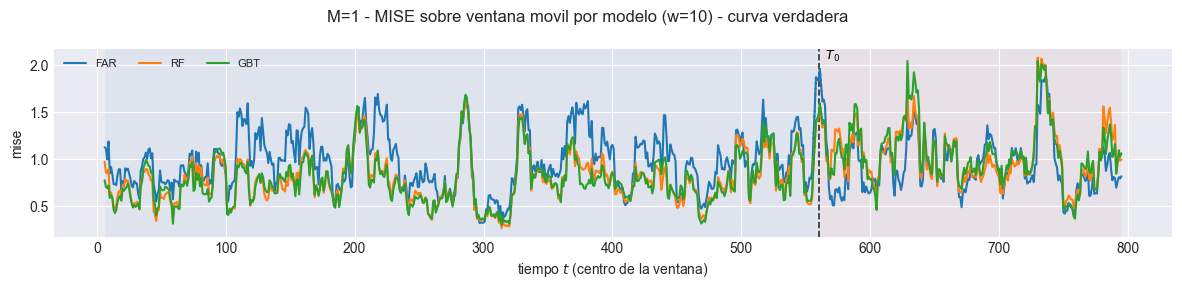

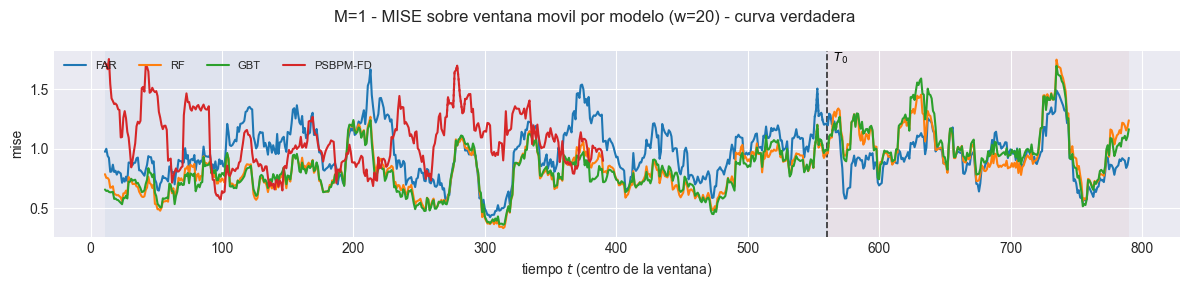

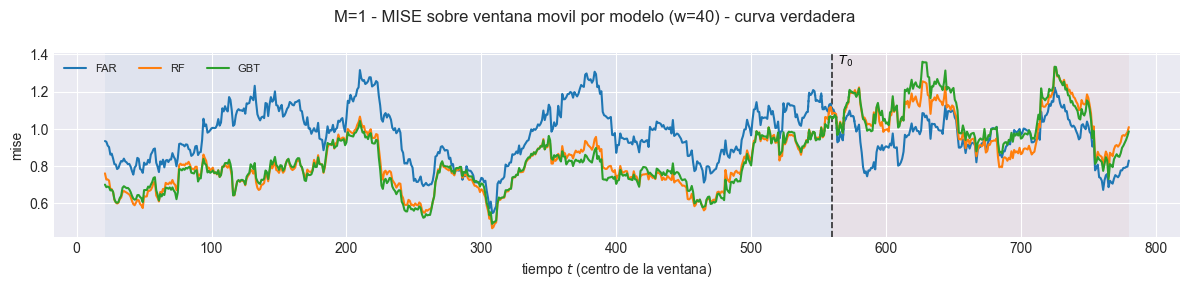

M=1 dibuja: ['FAR', 'GBT', 'PSBPM-FD', 'RF']


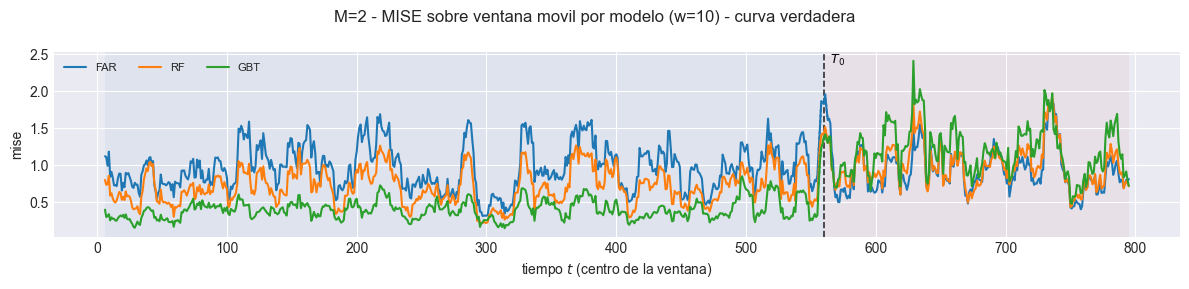

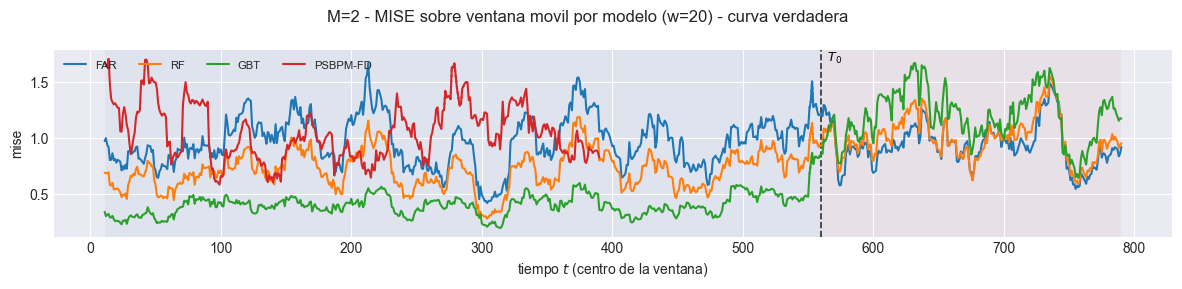

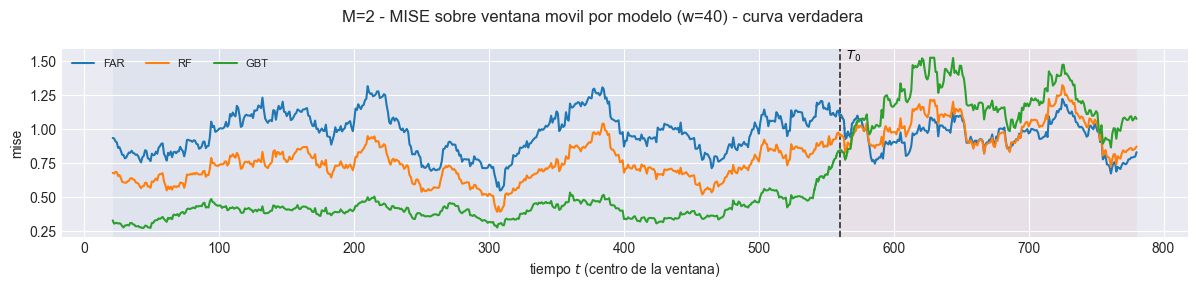

M=2 dibuja: ['FAR', 'GBT', 'PSBPM-FD', 'RF']


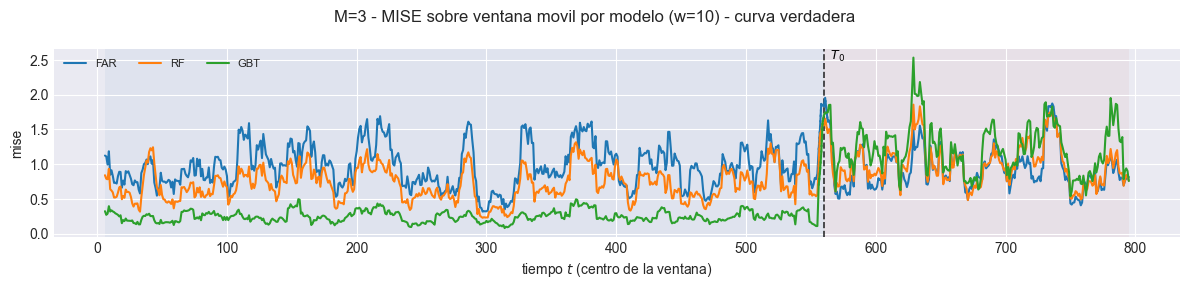

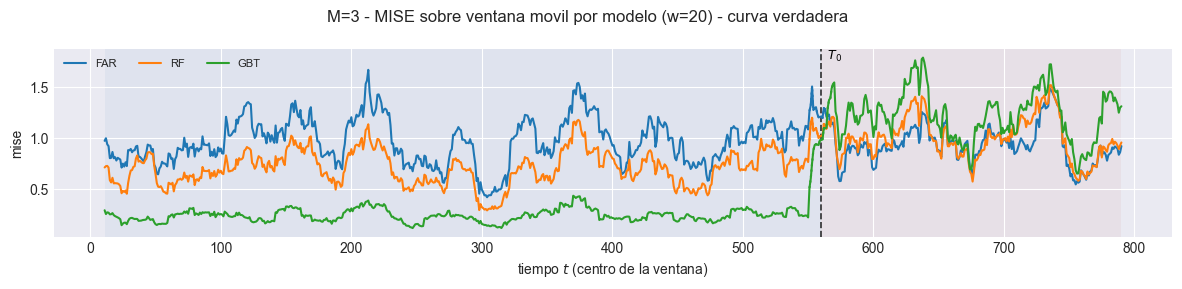

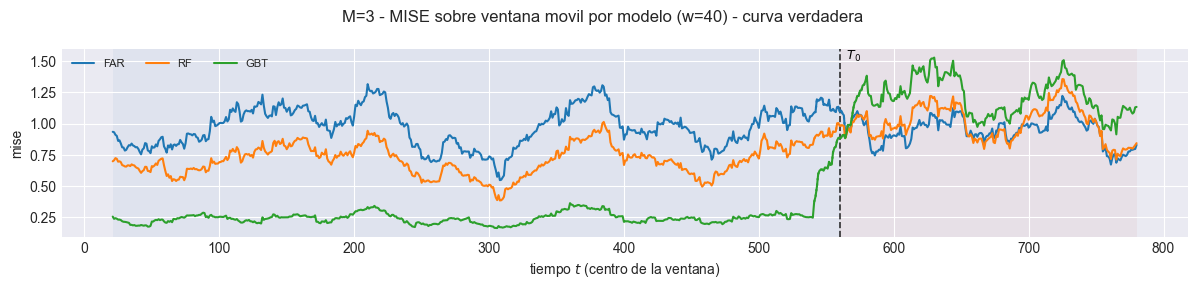

M=3 dibuja: ['FAR', 'GBT', 'RF']

excluidas de TODAS las figuras: ['(truncamiento FPCA)', 'media', 'persistencia'] - siguen en las tablas y en los CSV


In [19]:
# Una figura por ancho y por M, con SOLO los modelos (ver EXCLUIR_DE_FIGURA).
fuera = set(EXCLUIR_DE_FIGURA)

for M in EST:
    e = EST[M]
    for w in VENTANAS_W:
        tw = e["tablas_w"][w]
        tf = tw[~tw["modelo"].isin(fuera)].copy()
        tf.attrs["w"] = w
        plot_ventana_movil(
            tf, T0, ["mise"], columna_grupo="modelo",
            estilos=ESTILOS_VENTANA,
            title=f"M={M} - MISE sobre ventana movil por modelo (w={w}) - "
                  "curva verdadera",
            save_path=str(e["paths"]["out_report"]
                          / f"{PREFIJO + 2}_ventana_modelos_w{w}.png"),
            verbose=False)
        plt.show()
    print(f"M={M} dibuja: "
          f"{sorted(set(e['ventana_df']['modelo'].unique()) - fuera)}")
print("\nexcluidas de TODAS las figuras:", sorted(fuera),
      "- siguen en las tablas y en los CSV")

In [ ]:
# La ventana móvil del Bloque A, modelo por modelo. Se dibuja aparte de la de
# MISE para no cambiarla, y con las mismas exclusiones: las líneas base y el
# piso estiran el eje y comprimen las diferencias entre competidores.
for M in EST:
    e = EST[M]
    tw = e["tablas_w"][W_COMP]
    tf = tw[~tw["modelo"].isin(fuera)].copy()
    tf.attrs["w"] = W_COMP

    disponibles = [c for c in ("mae_f", "rmse_f", "q95_abs")   # Q0.95, NO el supremo puro (linf_medio)
                   if c in tf.columns and tf[c].notna().any()]
    if not disponibles:
        print(f"[M={M}] la tabla de ventana no trae el Bloque A "
              "(¿PSBPM-FD leído del CSV del _04 sin esas columnas?).")
        continue

    plot_ventana_movil(
        tf, T0, disponibles, columna_grupo="modelo", estilos=ESTILOS_VENTANA,
        title=f"M={M} · Bloque A (MAE, RMSE, Q0.95) sobre la ventana móvil "
              f"por modelo (w={W_COMP}) — curva verdadera",
        save_path=str(e["paths"]["out_report"]
                      / f"78_ventana_bloqueA_modelos_w{W_COMP}.png"),
        verbose=False)
    plt.show()

    # La cadena, también aquí y por modelo: si se rompe en una sola serie, el
    # problema está en cómo se construyó esa predicción, no en las métricas.
    sub = tf.dropna(subset=disponibles)
    if {"mae_f", "rmse_f"} <= set(disponibles):
        assert (sub["mae_f"] <= sub["rmse_f"] + 1e-9).all(), (
            f"[M={M}] mae_f > rmse_f en alguna ventana de algún modelo.")
    print(f"[M={M}] Bloque A dibujado para "
          f"{sorted(sub['modelo'].unique())}")

    # ¿Cuánto se separan realmente las dos series que ESTILOS_VENTANA
    # desempata? Se mide aquí y no se da por sabido: la separación depende del
    # escenario, y en uno donde la media condicional no sea lineal el FAR
    # debería despegarse y el estilo dejaría de hacer falta.
    piv = tw.pivot_table(index="t_centro", columns="modelo", values="mise")
    if {"FAR", "PSBPM-FD"} <= set(piv.columns):
        dif = (piv["FAR"] - piv["PSBPM-FD"]).abs()
        rango = float(np.ptp(piv[[c for c in piv.columns if c not in fuera]].values))
        frac = float(dif.max()) / max(rango, 1e-12)
        print(f"        FAR vs PSBPM-FD: corr={piv['FAR'].corr(piv['PSBPM-FD']):.6f}"
              f"  máx|dif|={dif.max():.4f} = {frac:.1%} del eje vertical"
              + ("   <- se tapan: el estilo distintivo es lo que las separa"
                 if frac < 0.10 else "   (se distinguen sin ayuda del estilo)"))


In [ ]:
# Resumen SIMPLE del Bloque A: una fila por modelo, MAE / RMSE / Q0.95,
# train y test. Sin colorear ninguna columna como "ganadora": eso lo hace
# la celda de mas arriba, que ya declaro cual es la PRIMARIA.
for M in EST:
    e = EST[M]
    tabla = (e["A_df"][["mae_f", "rmse_f", "q95_abs_medio"]]
             .rename(columns={"mae_f": "MAE", "rmse_f": "RMSE",
                              "q95_abs_medio": "Q0.95"})
             .unstack("bloque")
             .swaplevel(axis=1).sort_index(axis=1))
    tabla = tabla[["train", "test"]]
    tabla.to_csv(e["paths"]["out_report"] / "77b_resumen_simple_bloqueA.csv")
    e["resumen_A_simple"] = tabla
    display(tabla.style.format("{:.6f}")
            .set_caption(f"M={M} · Bloque A · MAE / RMSE / Q0.95 por modelo, "
                         "train y test"))


## 6.1 Bloque B: el intervalo del FAR sale de su propio modelo

Hasta aquí el Bloque B era el PSBPM-FD contra nada. Deja de serlo, y la razón
es que el FAR **no es un predictor puntual**: es el modelo

$$X_{t+1} = \rho(X_t) + \varepsilon_{t+1},\qquad
\varepsilon \sim (0,\ \Sigma_\varepsilon)$$

de modo que su ley condicional a un paso está especificada por el método mismo
y su intervalo es el clásico del AR — centro en $\hat\rho(X_t)$, dispersión la
de la innovación estimada con los residuos de entrenamiento. **No hay ningún
supuesto adicional al que el FAR ya hace.** Es la misma extensión que en el AR
escalar lleva de $\hat y = \hat\phi y_t$ a $\hat y \pm z\,\hat\sigma_\varepsilon$.

$\hat\sigma_\varepsilon(\tau)$ es la **diagonal de $\Sigma_\varepsilon$**, así
que la banda no tiene ancho constante: se ensancha donde la innovación
funcional es más volátil. Lo que no puede hacer es ensancharse según el
**origen** — $\Sigma_\varepsilon$ es la misma para todo $t$. En el Escenario 1,
homogéneo y gaussiano, eso es exactamente correcto; en el 2 sería una
limitación real del competidor, y justamente la que el PSBPM-FD explota.

**Tres filas, no dos.** Al PSBPM-FD se le construye también esta banda, además
de la suya por cuantiles de la predictiva. Sin esa tercera fila no se puede
separar *gana porque su predictiva es mejor* de *gana porque el mecanismo de
intervalo es distinto*.

Sesgos que hay que declarar: $\hat\sigma_\varepsilon$ se estima **dentro de
muestra**, de modo que la banda gaussiana sale algo angosta y su Winkler algo
mejor de lo debido — sesgo que afecta por igual a las dos filas gaussianas y
no a la bayesiana, que sí integra la incertidumbre de los parámetros. Los
residuos se miden contra la curva **verdadera**, el mismo objetivo con que se
evalúa: contra la observada, $\hat\sigma_\varepsilon$ absorbería $\sigma_{obs}$
y la banda del competidor sería más ancha por una razón ajena a su calidad.

`RF`, `GBT` y las líneas base siguen fuera: no son modelos de probabilidad y
darles un intervalo exigiría un supuesto que ellos no hacen.

In [ ]:
# Construcción de las bandas. Los residuos son los del bloque de
# entrenamiento contra la curva VERDADERA, que es el objetivo de evaluación.
BANDAS = {}          # {M: {nombre_fila: (li, ls)}}

for M in EST:
    e = EST[M]
    n_train = int(es_train.sum())
    # Corrección de primer orden por rho estimado: en el AR escalar la varianza
    # de predicción a un paso es sigma^2 (1 + p/n). Aquí p son las kn
    # direcciones que el FAR retiene. Es pequeña -del orden del 0.5 %- y se
    # aplica para poder declarar que se tuvo en cuenta, no porque cambie nada.
    corr = (np.sqrt(1.0 + e["far_kn"] / n_train)
            if IC_CORRECCION_ESTIMACION else None)

    bandas = {}

    # -- FAR: el intervalo que implica su propio modelo --------------------
    X_far = e["curvas_desde_scores_std"](e["PRED"]["FAR"])
    r_far = residuos_para_banda(X_true_ev, X_far, es_train)
    bandas["FAR (IC del modelo AR)"] = (
        banda_predictiva_modelo(X_far, r_far, nivel=NIVEL_IC,
                                por_tau=IC_POR_TAU,
                                correccion_estimacion=corr),
        X_far)

    # -- PSBPM-FD: la MISMA banda, para aislar el mecanismo ----------------
    if IC_PSBP_TAMBIEN_GAUSSIANA and e["X_pred_psbp"] is not None:
        r_ps = residuos_para_banda(X_true_ev, e["X_pred_psbp"], es_train)
        bandas["PSBPM-FD (IC gaussiano, mismo mecanismo)"] = (
            banda_predictiva_modelo(e["X_pred_psbp"], r_ps, nivel=NIVEL_IC,
                                    por_tau=IC_POR_TAU,
                                    correccion_estimacion=corr),
            e["X_pred_psbp"])

    # -- PSBPM-FD: su banda nativa, leída del artefacto del _04 ------------
    npz = e["paths"]["predict"] / "banda_funcional_psbp.npz"
    if npz.exists():
        z = np.load(npz, allow_pickle=False)
        assert z["li"].shape == X_true_ev.shape, (
            f"[M={M}] la banda del _04 es {z['li'].shape} y aquí hay "
            f"{X_true_ev.shape}: ¿corrieron con distinta partición?")
        assert abs(float(z["nivel"][0]) - NIVEL_IC) < 1e-9, (
            f"[M={M}] el _04 usó nivel {float(z['nivel'][0])} y aquí NIVEL_IC="
            f"{NIVEL_IC}: el Winkler de las dos filas no sería comparable.")
        bandas["PSBPM-FD (predictiva bayesiana)"] = (
            (z["li"].astype(float), z["ls"].astype(float)),
            z["X_pred"].astype(float))
    else:
        print(f"! [M={M}] falta {npz.name}: ejecuta 30_04 para persistir la "
              "banda nativa. Van solo las filas gaussianas.")

    BANDAS[M] = bandas
    sd = sigma_residual(r_far, por_tau=IC_POR_TAU)
    print(f"M={M}  kn={e['far_kn']}  corrección={corr if corr else 1.0:.4f}  "
          f"sigma_eps(tau) del FAR: min={sd.min():.4f} máx={sd.max():.4f} "
          f"(razón {sd.max()/sd.min():.2f})  ·  filas: {len(bandas)}")


In [ ]:
# Las cuatro cifras del Bloque B, por fila y por bloque. El Winkler es la
# PRIMARIA; picp y mpiw son su descomposición y no ordenan nada por su cuenta.
for M in EST:
    e = EST[M]
    filas = []
    for nombre, ((li, ls), _Xp) in BANDAS[M].items():
        for etq, mask in (("train", es_train), ("test", ~es_train)):
            r = resumen_intervalo(X_true_ev[mask], li[mask], ls[mask],
                                  nivel=NIVEL_IC, tau=grilla)
            filas.append({"banda": nombre, "bloque": etq,
                          **{k: r[k] for k in
                             ("winkler", "picp", "ee_picp", "ace", "mpiw")}})
    B_df = pd.DataFrame(filas).set_index(["bloque", "banda"]).sort_index()
    B_df.to_csv(e["paths"]["out_report"] / "80_bloqueB_modelos.csv")
    e["B_modelos"] = B_df

    display(B_df.loc["test"].style
            .format({"winkler": "{:.4f}", "picp": "{:.4f}", "ee_picp": "{:.4f}",
                     "ace": "{:+.4f}", "mpiw": "{:.4f}"})
            .background_gradient(subset=["winkler"], cmap="RdYlGn_r")
            .set_caption(f"M={M} · Bloque B, bloque de PRUEBA · PRIMARIA: "
                         f"winkler · nivel nominal {NIVEL_IC:.0%}"))

    # La lectura de tres filas, que es la razón de haberlas construido.
    te_ = B_df.loc["test"]
    g_far = "FAR (IC del modelo AR)"
    g_psg = "PSBPM-FD (IC gaussiano, mismo mecanismo)"
    g_psb = "PSBPM-FD (predictiva bayesiana)"
    if {g_far, g_psg} <= set(te_.index):
        d_modelo = te_.loc[g_psg, "winkler"] - te_.loc[g_far, "winkler"]
        print(f"[M={M}] mismo MECANISMO de banda, distinto MODELO: "
              f"PSBPM-FD - FAR = {d_modelo:+.4f} de Winkler")
    if {g_psg, g_psb} <= set(te_.index):
        d_mec = te_.loc[g_psb, "winkler"] - te_.loc[g_psg, "winkler"]
        print(f"        mismo MODELO, distinto MECANISMO: bayesiana - gaussiana "
              f"= {d_mec:+.4f}")
        print("        Si el segundo domina al primero, lo que separa a las")
        print("        filas es la forma de la predictiva y no la calidad de la")
        print("        media condicional; si domina el primero, al revés.")


In [ ]:
# Winkler sobre la ventana móvil, y su descomposición. Es la vista que dice
# CUÁNDO la banda falla, no solo cuánto: una cobertura marginal correcta puede
# esconder rachas enteras de violaciones.
from model_psbp_fd.fit import pesos_normalizados as _pn
_w_dom = _pn(grilla, PESOS_TAU)

for M in EST:
    e = EST[M]
    partes = []
    for nombre, ((li, ls), Xp) in BANDAS[M].items():
        t_ = ventana_movil_funcional(X_true_ev, Xp, grilla, T0_orig, w=W_COMP,
                                     li=li, ls=ls, t_offset=N_LAGS,
                                     pesos_tau=PESOS_TAU, q_extremo=Q_EXTREMO,
                                     nivel=NIVEL_IC, bloque_A=True,
                                     verbose=False)
        t_["banda"] = nombre
        partes.append(t_)
    vb = pd.concat(partes, ignore_index=True)
    vb.attrs["w"] = W_COMP
    vb.to_csv(e["paths"]["out_report"] / f"81_ventana_bloqueB_w{W_COMP}.csv",
              index=False)
    e["ventana_B"] = vb

    plot_ventana_movil(
        vb, T0, ["winkler", "picp", "mpiw"], columna_grupo="banda",
        title=f"M={M} · Bloque B sobre la ventana móvil (w={W_COMP}) — "
              "winkler es la primaria; picp y mpiw lo descomponen",
        save_path=str(e["paths"]["out_report"]
                      / f"81_ventana_bloqueB_w{W_COMP}.png"),
        verbose=False)
    plt.show()


# Metrica 5: el indicador de cobertura I_t por origen, del que picp (6) es
# el promedio. Se persiste por banda para poder ver DONDE falla, no solo
# cuanto en promedio.
for nombre, ((li, ls), _Xp) in BANDAS[M].items():
    I_t = indicador_cobertura(X_true_ev, li, ls).mean(axis=1)
    ind = pd.DataFrame({"t": np.arange(len(I_t)) + N_LAGS + 1,
                        "bloque": np.where(es_train, "train", "test"),
                        "banda": nombre, "I_t": I_t})
    ind.to_csv(e["paths"]["out_report"]
              / f"81b_indicador_cobertura_{nombre.split(' ')[0]}.csv",
              index=False)


In [ ]:
# Resumen SIMPLE del Bloque B: una fila por banda (FAR y PSBPM-FD), Winkler
# / PICP / MPIW, train y test. El indicador I_t (metrica 5) queda en su
# propio CSV por origen -- no cabe en una tabla de una cifra por celda.
for M in EST:
    e = EST[M]
    tabla = (e["B_modelos"][["winkler", "picp", "mpiw"]]
             .rename(columns={"winkler": "Winkler", "picp": "PICP",
                              "mpiw": "MPIW"})
             .unstack("bloque")
             .swaplevel(axis=1).sort_index(axis=1))
    tabla = tabla[["train", "test"]]
    tabla.to_csv(e["paths"]["out_report"] / "80b_resumen_simple_bloqueB.csv")
    e["resumen_B_simple"] = tabla
    display(tabla.style.format("{:.4f}")
            .set_caption(f"M={M} · Bloque B · Winkler / PICP / MPIW por "
                         f"banda, train y test · nivel nominal {NIVEL_IC:.0%}"))


In [ ]:
# ¿Sobrevive la diferencia de Winkler al remuestreo? Con R = 1 es la única
# forma de saberlo, y el Winkler por origen es exactamente la serie que hay que
# pasar por el bootstrap de bloques.
for M in EST:
    e = EST[M]
    filas = []
    for nombre, ((li, ls), _Xp) in BANDAS[M].items():
        w_t = winkler(X_true_ev[~es_train], li[~es_train], ls[~es_train],
                      nivel=NIVEL_IC) @ _w_dom
        I_t = indicador_cobertura(X_true_ev[~es_train], li[~es_train],
                                  ls[~es_train]).mean(axis=1)
        for metrica, v in (("winkler", w_t), ("picp", I_t)):
            d = bootstrap_bloques(v, estadistico=np.mean,
                                  largo_bloque=BOOT_BLOQUE, B=BOOT_B,
                                  nivel=0.95, seed=BOOT_SEED)
            filas.append({"banda": nombre, "metrica": metrica,
                          "observado": d["observado"], "li": d["li"],
                          "ls": d["ls"], "largo_bloque": d["largo_bloque"],
                          "n": d["n"]})
    bb = pd.DataFrame(filas).set_index(["metrica", "banda"]).sort_index()
    bb.to_csv(e["paths"]["out_report"] / "82_bootstrap_bloqueB.csv")
    e["boot_B"] = bb

    display(bb.loc["winkler"].sort_values("observado").style
            .format({"observado": "{:.4f}", "li": "{:.4f}", "ls": "{:.4f}"})
            .set_caption(f"M={M} · Winkler en el test con intervalo bootstrap "
                         "de bloques al 95 %"))

    w_ = bb.loc["winkler"].sort_values("observado")
    mejor = w_.index[0]
    print(f"[M={M}] mejor Winkler: {mejor} ({w_.iloc[0]['observado']:.4f})")
    for nombre, f_ in w_.iloc[1:].iterrows():
        solapa = (f_["li"] <= w_.iloc[0]["ls"]) and (w_.iloc[0]["li"] <= f_["ls"])
        print(f"        vs {nombre:42s} {f_['observado']:.4f}  "
              + ("solapa: no distinguible con R=1" if solapa
                 else "no solapa: la diferencia sobrevive"))


In [20]:
# Lectura numerica del salto en T0 por modelo, excluyendo las ventanas que lo
# cruzan. Aqui SI van todas las series: en una tabla las lineas base no
# estorban y son la referencia con la que se lee el resto.
for M in EST:
    e = EST[M]
    limpio = e["ventana_df"][~e["ventana_df"]["cruza_T0"]]
    salto = (limpio.groupby(["modelo", "bloque"])["mise"].mean()
             .unstack("bloque")
             .rename(columns={"train": "MISE_train", "test": "MISE_test"}))
    salto["salto"] = salto["MISE_test"] / salto["MISE_train"]
    salto = salto.sort_values("MISE_test")
    salto.to_csv(e["paths"]["out_report"] / f"{PREFIJO + 3}_salto_T0.csv")
    e["salto_df"] = salto

    display(salto.style.format({"MISE_train": "{:.6f}", "MISE_test": "{:.6f}",
                                "salto": "{:.2f}x"})
            .background_gradient(subset=["MISE_test"], cmap="RdYlGn_r")
            .set_caption(f"M={M} - MISE medio por bloque y salto en T0 "
                         f"(w={W_COMP}, ventanas que cruzan excluidas)"))

bloque,MISE_test,MISE_train,salto
modelo,,,
(truncamiento FPCA),0.218418,0.252543,0.86x
FAR,0.932822,0.965108,0.97x
RF,1.036784,0.770779,1.35x
GBT,1.061375,0.764955,1.39x
PSBPM-FD,1.085805,1.038036,1.05x
persistencia,1.110060,1.119426,0.99x
media,1.342689,1.475093,0.91x


bloque,MISE_test,MISE_train,salto
modelo,,,
(truncamiento FPCA),0.034807,0.035496,0.98x
FAR,0.932822,0.965108,0.97x
RF,1.000667,0.712108,1.41x
PSBPM-FD,1.067191,1.020522,1.05x
GBT,1.201253,0.401067,3.00x
persistencia,1.211656,1.204560,1.01x
media,1.342689,1.475093,0.91x


bloque,MISE_test,MISE_train,salto
modelo,,,
(truncamiento FPCA),0.005770,0.005471,1.05x
FAR,0.932821,0.965108,0.97x
RF,0.999624,0.705256,1.42x
GBT,1.220498,0.243982,5.00x
persistencia,1.230113,1.233426,1.00x
media,1.342689,1.475093,0.91x


## 7. Contraste con el PSBPM-FD, dentro de cada $M$

Las cifras agregadas del modelo propuesto se leen de los CSV de `30_04`. La
que decide el eje 1 es el **MISE en el bloque de prueba**.

In [21]:
for M in EST:
    e = EST[M]
    f_s = e["paths"]["out_report"] / "50_metricas_scores.csv"
    f_f = e["paths"]["out_report"] / "51_metricas_funcionales.csv"

    psbp = {}
    if f_s.exists() and f_f.exists():
        _s = pd.read_csv(f_s, index_col=[0, 1])
        _f = pd.read_csv(f_f, index_col=0)
        for b in ("train", "test"):
            psbp[b] = {"RMSE_scores": float(_s.loc[b, "RMSE"].mean()),
                       "R2_scores":   float(_s.loc[b, "R2"].mean()),
                       "MISE":        float(_f.loc[b, "MISE"]),
                       "RMSE_func":   float(_f.loc[b, "RMSE_f"])}
        print(f"OK [M={M}] cifras del PSBPM-FD leidas de 50_/51_   "
              f"MISE test = {psbp['test']['MISE']:.6f}")
    else:
        print(f"! [M={M}] faltan 50_metricas_scores.csv y/o "
              "51_metricas_funcionales.csv. Ejecuta 30_04 para este M.")
    e["psbp"] = psbp

OK [M=1] cifras del PSBPM-FD leidas de 50_/51_   MISE test = 1.082947
OK [M=2] cifras del PSBPM-FD leidas de 50_/51_   MISE test = 1.066227
! [M=3] faltan 50_metricas_scores.csv y/o 51_metricas_funcionales.csv. Ejecuta 30_04 para este M.


In [22]:
for M in EST:
    e = EST[M]
    if not e["psbp"]:
        continue
    filas = []
    for b in ("train", "test"):
        filas.append({"bloque": b, "modelo": "PSBPM-FD", **e["psbp"][b]})
        for nom in e["PRED"]:
            r = e["comp_df"].loc[(b, nom)]
            filas.append({"bloque": b, "modelo": nom,
                          "RMSE_scores": float(r["RMSE_scores"]),
                          "R2_scores": float(r["R2_scores"]),
                          "MISE": float(r["MISE"]),
                          "RMSE_func": float(r["RMSE_func"])})
        filas.append({"bloque": b, "modelo": "(truncamiento FPCA)",
                      "RMSE_scores": np.nan, "R2_scores": np.nan,
                      "MISE": e["MISE_TRUNC"][b], "RMSE_func": np.nan})

    final_df = pd.DataFrame(filas).set_index(["bloque", "modelo"])
    # La primera fila de cada bloque es, por construccion, la del PSBPM-FD.
    ref_bloque = final_df.groupby("bloque")["MISE"].transform(lambda s: s.iloc[0])
    final_df["MISE_rel_PSBP"] = final_df["MISE"] / ref_bloque
    final_df.to_csv(e["paths"]["out_report"] / f"{PREFIJO + 4}_tabla_final.csv")
    e["final_df"] = final_df

    display(final_df.style
            .format({"RMSE_scores": "{:.4f}", "R2_scores": "{:.4f}",
                     "MISE": "{:.6f}", "RMSE_func": "{:.6f}",
                     "MISE_rel_PSBP": "{:.3f}x"}, na_rep="-")
            .background_gradient(subset=["MISE"], cmap="RdYlGn_r")
            .set_caption(f"M={M} - tabla del eje 1 · MISE contra la curva "
                         "VERDADERA · MISE_rel_PSBP < 1 significa mejor que el "
                         "PSBPM-FD"))

In [23]:
for M in EST:
    e = EST[M]
    if not e["psbp"]:
        continue
    print(f"══ M={M} ══ veredicto sobre el bloque de PRUEBA (MISE, menor es mejor)")
    ref = e["psbp"]["test"]["MISE"]
    orden = (e["final_df"].loc["test", "MISE"]
             .drop(index=["(truncamiento FPCA)"]).sort_values())
    for i, (nom, v) in enumerate(orden.items(), 1):
        marca = "   <- PSBPM-FD" if nom == "PSBPM-FD" else ""
        print(f"  {i}. {nom:22s} MISE={v:.6f}   ({v / ref:.3f}x){marca}")

    mejores = [n for n, v in orden.items() if v < ref]
    e["rango_psbp"] = int(list(orden.index).index("PSBPM-FD")) + 1
    e["n_mejores"] = len(mejores)
    if not mejores:
        print("  El PSBPM-FD domina en MISE a todas las referencias en el test.")
    else:
        print(f"  Superan al PSBPM-FD en MISE: {', '.join(mejores)}")

    piso = e["MISE_TRUNC"]["test"] / ref
    e["piso_rel"] = float(piso)
    print(f"  El piso de truncamiento es {piso:.1%} del MISE del PSBPM-FD en test."
          + ("\n    <- la representacion domina el error; subir M rinde mas que "
             "cambiar de modelo" if piso > 0.7 else ""))
    print()

print("En el Escenario 1 -FAR(1) lineal gaussiano- que el FAR empate")
print("o ganen NO es un fracaso: es el escenario correctamente especificado")
print("para ellos, y el precio de la flexibilidad. Esa brecha es la cota con la")
print("que se leen los escenarios 2-6.")

══ M=1 ══ veredicto sobre el bloque de PRUEBA (MISE, menor es mejor)
  1. FAR                    MISE=0.954522   (0.881x)
  2. RF                     MISE=1.058087   (0.977x)
  3. GBT                    MISE=1.079268   (0.997x)
  4. PSBPM-FD               MISE=1.082947   (1.000x)   <- PSBPM-FD
  5. persistencia           MISE=1.136923   (1.050x)
  6. media                  MISE=1.358731   (1.255x)
  Superan al PSBPM-FD en MISE: FAR, RF, GBT
  El piso de truncamiento es 21.1% del MISE del PSBPM-FD en test.

══ M=2 ══ veredicto sobre el bloque de PRUEBA (MISE, menor es mejor)
  1. FAR                    MISE=0.954522   (0.895x)
  2. RF                     MISE=1.009312   (0.947x)
  3. PSBPM-FD               MISE=1.066227   (1.000x)   <- PSBPM-FD
  4. GBT                    MISE=1.200264   (1.126x)
  5. persistencia           MISE=1.236302   (1.160x)
  6. media                  MISE=1.358731   (1.274x)
  Superan al PSBPM-FD en MISE: FAR, RF
  El piso de truncamiento es 3.3% del MISE del P

## 8. El barrido: todos los modelos contra $M$

Ésta es la sección que el barrido hace posible, y la que decide entre las dos
explicaciones que un solo $M$ no distingue.

**Todos los competidores viven sobre la misma representación FPCA.** Por eso, si
al subir $M$ el MISE de prueba se degrada en el FAR, el RF y el
PSBPM-FD por igual, el responsable es la **representación** —componentes de
varianza baja que el estandarizador amplifica hasta volverlas ruido con la
misma escala que la señal— y no el modelo propuesto. Si en cambio la
degradación es **específica del PSBPM-FD**, queda respaldado el mecanismo de la
Etapa D: $M$ entra dos veces, y su segunda entrada —$p=qM$ covariables en la
regresión probit de pesos **compartidos entre átomos**— diluye el prior de
selección y estropea la asignación de la mezcla también para las componentes
buenas.

La cifra que separa ambas cosas es la **razón `MISE_modelo / MISE_FAR`** dentro
de cada $M$: normaliza por lo que la representación le hace a todo el mundo, y
deja a la vista sólo la parte diferencial.

In [24]:
filas = []
for M in EST:
    e = EST[M]
    for bloque in ("train", "test"):
        for nom in MODELOS + ["(truncamiento FPCA)"]:
            r = e["comp_df"].loc[(bloque, nom)]
            filas.append({
                "M": M, "bloque": bloque, "modelo": nom,
                "MISE": float(r["MISE"]),
                "RMSE_func": float(r["RMSE_func"]),
                "RMSE_scores": float(r["RMSE_scores"]),
                "R2_scores": float(r["R2_scores"]),
            })
        if e["psbp"]:
            p = e["psbp"][bloque]
            filas.append({
                "M": M, "bloque": bloque, "modelo": "PSBPM-FD",
                "MISE": p["MISE"], "RMSE_func": p["RMSE_func"],
                "RMSE_scores": p["RMSE_scores"], "R2_scores": p["R2_scores"],
            })

modelos_M = pd.DataFrame(filas)

# Razon contra el FAR DENTRO de cada (M, bloque): normaliza por lo que la
# representacion le hace a todos por igual.
_var = (modelos_M[modelos_M.modelo == "FAR"]
        .set_index(["M", "bloque"])["MISE"].rename("MISE_FAR"))
modelos_M = modelos_M.join(_var, on=["M", "bloque"])
modelos_M["MISE_rel_FAR"] = modelos_M["MISE"] / modelos_M["MISE_FAR"]
modelos_M.to_csv(PATH_BARRIDO / "90_comparacion_modelos_por_M.csv", index=False)

piv_mise = (modelos_M[modelos_M.bloque == "test"]
            .pivot(index="modelo", columns="M", values="MISE"))
display(piv_mise.style.format("{:.6f}", na_rep="-")
        .background_gradient(cmap="RdYlGn_r", axis=None)
        .set_caption("MISE en el bloque de PRUEBA · filas = modelo, "
                     "columnas = M · menor es mejor"))

M,1,2,3
modelo,,,
(truncamiento FPCA),0.228561,0.034991,0.005754
FAR,0.954522,0.954522,0.954522
GBT,1.079268,1.200264,1.241378
PSBPM-FD,1.082947,1.066227,-
RF,1.058087,1.009312,1.016245
media,1.358731,1.358731,1.358731
persistencia,1.136923,1.236302,1.255341


In [25]:
piv_rel = (modelos_M[modelos_M.bloque == "test"]
           .pivot(index="modelo", columns="M", values="MISE_rel_FAR"))
display(piv_rel.style.format("{:.3f}", na_rep="-")
        .background_gradient(cmap="RdYlGn_r", axis=None)
        .set_caption("MISE relativo al VAR dentro de cada M (test) · el VAR es "
                     "1.000 por construcción · > 1 significa peor que el FAR"))

print("Lectura: una fila que crece con M mientras las demás se mantienen es una")
print("degradación ESPECÍFICA de ese modelo. Si crecen todas a la vez, lo que")
print("se degrada es la representación y no el modelo.")

M,1,2,3
modelo,,,
(truncamiento FPCA),0.239,0.037,0.006
FAR,1.000,1.000,1.000
GBT,1.131,1.257,1.301
PSBPM-FD,1.135,1.117,-
RF,1.108,1.057,1.065
media,1.423,1.423,1.423
persistencia,1.191,1.295,1.315


Lectura: una fila que crece con M mientras las demás se mantienen es una
degradación ESPECÍFICA de ese modelo. Si crecen todas a la vez, lo que
se degrada es la representación y no el modelo.


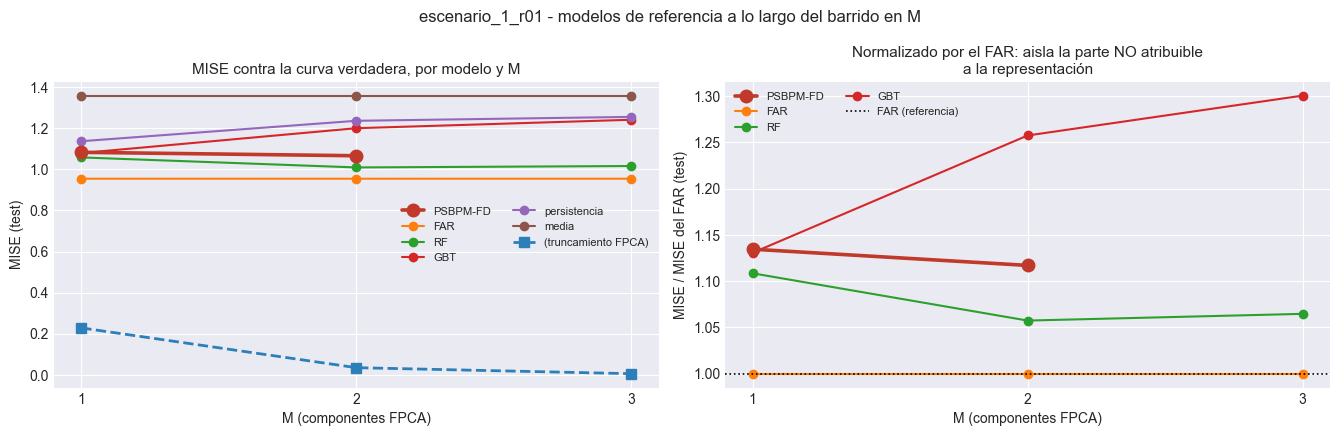

In [26]:
# Figura del barrido: MISE de test por modelo contra M, en escala absoluta y
# relativa al VAR. Las lineas base y el piso van en el panel absoluto porque
# ahi son la referencia, y fuera del relativo porque lo comprimen.
te = modelos_M[modelos_M.bloque == "test"]
_Ms = sorted(te["M"].unique())
# En §8 las lineas base y el piso SI van en el panel absoluto: ahi son la
# referencia con la que se lee todo lo demas.
_REDUNDANTES = set()   # ya no hay competidores redundantes (§3.2)
_orden = [m for m in ["PSBPM-FD", "FAR", "RF", "GBT",
                      "persistencia", "media", "(truncamiento FPCA)"]
          if m in set(te["modelo"]) and m not in _REDUNDANTES]
if _REDUNDANTES:
    print(f"fuera de la figura por redundantes: {sorted(_REDUNDANTES)}"
          "   (siguen en las tablas de arriba)")
_estilo = {"PSBPM-FD": dict(color="#c0392b", lw=2.6, ms=9, marker="o", zorder=5),
           "(truncamiento FPCA)": dict(color="#2c7fb8", lw=2.0, ms=7,
                                       marker="s", ls="--")}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

ax = axes[0]
for i, nom in enumerate(_orden):
    s = te[te.modelo == nom].set_index("M")["MISE"].reindex(_Ms)
    kw = _estilo.get(nom, dict(color=plt.cm.tab10(i % 10), lw=1.5, ms=6,
                               marker="o"))
    ax.plot(_Ms, s.to_numpy(), label=nom, **kw)
ax.set_ylabel("MISE (test)")
ax.set_title("MISE contra la curva verdadera, por modelo y M", fontsize=11)
ax.legend(fontsize=8, ncol=2)

ax = axes[1]
for i, nom in enumerate(_orden):
    if nom in ("media", "persistencia", "(truncamiento FPCA)"):
        continue
    s = te[te.modelo == nom].set_index("M")["MISE_rel_FAR"].reindex(_Ms)
    kw = _estilo.get(nom, dict(color=plt.cm.tab10(i % 10), lw=1.5, ms=6,
                               marker="o"))
    ax.plot(_Ms, s.to_numpy(), label=nom, **kw)
ax.axhline(1.0, color="k", ls=":", lw=1.2, label="FAR (referencia)")
ax.set_ylabel("MISE / MISE del FAR (test)")
ax.set_title("Normalizado por el FAR: aisla la parte NO atribuible\n"
             "a la representación", fontsize=11)
ax.legend(fontsize=8, ncol=2)

for ax in axes:
    ax.set_xticks(_Ms); ax.set_xlabel("M (componentes FPCA)")
fig.suptitle(f"{EXPERIMENT_BASE} - modelos de referencia a lo largo del "
             "barrido en M", fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "91_mise_modelos_vs_M.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# Ranking por M: en que puesto queda el PSBPM-FD dentro de cada punto del
# barrido, y contra cuantos pierde. Es la lectura del eje 1 resumida a dos
# numeros por M.
filas_r = []
for M in EST:
    e = EST[M]
    if not e["psbp"]:
        continue
    orden = (e["final_df"].loc["test", "MISE"]
             .drop(index=["(truncamiento FPCA)"]).sort_values())
    filas_r.append({
        "M": M,
        "puesto_PSBPM": e["rango_psbp"],
        "de_n_modelos": int(len(orden)),
        "n_que_lo_superan": e["n_mejores"],
        "MISE_PSBPM": float(e["psbp"]["test"]["MISE"]),
        "MISE_mejor": float(orden.iloc[0]),
        "mejor_modelo": str(orden.index[0]),
        "MISE_FAR": float(e["comp_df"].loc[("test", "FAR"), "MISE"]),
        "MISE_truncamiento": float(e["MISE_TRUNC"]["test"]),
        "piso_sobre_PSBPM": e["piso_rel"],
        "far_hs": e["far_hs"], "far_hs_referencia": HS_REFERENCIA,
        "far_kn": e["far_kn"],
        "far_condicion": round(e["far_cond"], 3),
        "sep_vs_far_scores_retirado": round(
            e["sep_far_viejo"]["max_relativo_sd"], 6),
        "var_explicada": e["var_explicada"],
    })

ranking_df = pd.DataFrame(filas_r).set_index("M")
ranking_df.to_csv(PATH_BARRIDO / "92_ranking_por_M.csv")

display(ranking_df.style
        .format({"MISE_PSBPM": "{:.6f}", "MISE_mejor": "{:.6f}",
                 "MISE_FAR": "{:.6f}", "MISE_truncamiento": "{:.6f}",
                 "piso_sobre_PSBPM": "{:.1%}", "far_hs": "{:.4f}",
                 "var_explicada": "{:.4%}"}, na_rep="-")
        .set_caption("Posición del PSBPM-FD dentro de cada punto del barrido "
                     "(bloque de prueba, MISE)"))

,puesto_PSBPM,de_n_modelos,n_que_lo_superan,MISE_PSBPM,MISE_mejor,mejor_modelo,MISE_FAR,MISE_truncamiento,piso_sobre_PSBPM,far_hs,far_hs_referencia,far_kn,far_condicion,sep_vs_far_scores_retirado,var_explicada
M,,,,,,,,,,,,,,,
1,4,6,3,1.082947,0.954522,FAR,0.954522,0.228561,21.1%,0.6454,0.70,1,1.000000,0.002924,82.9797%
2,3,6,2,1.066227,0.954522,FAR,0.954522,0.034991,3.3%,0.6454,0.70,1,1.000000,2.268843,97.6881%


In [28]:
# == Resumen ejecutable, uno por M ===========================================
partes = []
for M in EST:
    e = EST[M]
    resumen = {
        "M": M,
        "experiment_id": e["eid"],
        "objetivo_evaluacion": OBJETIVO,
        "modo_residuo": MODO_RESIDUO,
        "n_lags": N_LAGS, "M_fpca": e["M_fpca"], "K_base": e["K"],
        "var_explicada": round(e["var_explicada"], 6),
        "n_train_origenes": int(es_train.sum()),
        "n_test_origenes": int((~es_train).sum()),
        "w_ventana": W_COMP,
                "far_hs_norm": round(e["far_hs"], 6),
        "far_hs_referencia": HS_REFERENCIA,
        "far_kn": e["far_kn"],
        "far_condicion": round(e["far_cond"], 3),
        "sep_vs_far_scores_retirado": round(
            e["sep_far_viejo"]["max_relativo_sd"], 6),
        "mise_truncamiento_test": round(float(e["MISE_TRUNC"]["test"]), 8),
        **{f"mise_test_{n}": round(float(e["comp_df"].loc[("test", n), "MISE"]), 8)
           for n in e["PRED"]},
    }
    if e["psbp"]:
        resumen["mise_test_PSBPM-FD"] = round(e["psbp"]["test"]["MISE"], 8)

    pd.Series(resumen).to_csv(
        e["paths"]["out_report"] / f"{PREFIJO + 5}_resumen_comparacion.csv",
        header=False)
    partes.append(resumen)

    print(f"── M={M} ──")
    for k, v in resumen.items():
        print(f"  {k:26s}: {v}")
    print("  parametros declarados de cada competidor:")
    for n, txt in e["INFO"].items():
        print(f"    {n:14s}: {txt}")
    print()

resumen_M = pd.DataFrame(partes).set_index("M")
resumen_M.to_csv(PATH_BARRIDO / "93_resumen_comparacion_por_M.csv")
print(f"Por M: {[str(EST[M]['paths']['out_report']) for M in EST]}")
print(f"       (archivos {PREFIJO}-{PREFIJO + 5})")
print(f"Barrido: {PATH_BARRIDO}   (archivos 90-93)")

── M=1 ──
  M                         : 1
  experiment_id             : escenario_1_r01_m01
  objetivo_evaluacion       : curva_verdadera
  modo_residuo              : ninguno
  n_lags                    : 1
  M_fpca                    : 1
  K_base                    : 4
  var_explicada             : 0.829797
  n_train_origenes          : 559
  n_test_origenes           : 240
  w_ventana                 : 20
  far_hs_norm               : 0.645381
  far_hs_referencia         : 0.70
  far_kn                    : 1
  far_condicion             : 1.0
  sep_vs_far_scores_retirado: 0.002924
  mise_truncamiento_test    : 0.22856146
  mise_test_FAR             : 0.95452236
  mise_test_RF              : 1.05808662
  mise_test_GBT             : 1.07926793
  mise_test_media           : 1.3587309
  mise_test_persistencia    : 1.13692266
  mise_test_PSBPM-FD        : 1.08294688
  parametros declarados de cada competidor:
    FAR           : kn=1 (por far.cv/L2), ||rho||_HS=0.6454
    RF            :

In [29]:
# == Veredicto del barrido ===================================================
print("=" * 72)
print(f"  BARRIDO {EXPERIMENT_BASE}   ·   M evaluados: {sorted(EST)}")
print("=" * 72)

if "PSBPM-FD" in set(te["modelo"]):
    s_ps  = te[te.modelo == "PSBPM-FD"].set_index("M")["MISE_rel_FAR"].reindex(_Ms)
    otros = [m for m in _orden
             if m not in ("PSBPM-FD", "media", "persistencia",
                          "(truncamiento FPCA)")]
    print(f"  MISE relativo al VAR (test), por M:")
    for M in _Ms:
        fila = "   ".join(
            f"{m}={te[(te.modelo == m) & (te.M == M)]['MISE_rel_FAR'].iloc[0]:.3f}"
            for m in ["PSBPM-FD"] + otros
            if not te[(te.modelo == m) & (te.M == M)].empty)
        print(f"    M={M}:  {fila}")

    if len(_Ms) >= 2:
        d_ps = np.diff(s_ps.to_numpy())
        d_ot = np.mean([np.diff(te[te.modelo == m].set_index("M")["MISE_rel_FAR"]
                                .reindex(_Ms).to_numpy())
                        for m in otros], axis=0) if otros else None
        print("-" * 72)
        print(f"  cambio de MISE_rel_FAR del PSBPM-FD: "
              + "  ".join(f"{_Ms[i]}->{_Ms[i+1]}: {d:+.4f}"
                          for i, d in enumerate(d_ps)))
        if d_ot is not None:
            print(f"  ídem promediado sobre los otros competidores: "
                  + "  ".join(f"{_Ms[i]}->{_Ms[i+1]}: {d:+.4f}"
                              for i, d in enumerate(d_ot)))
            if np.all(d_ps > 0) and d_ot is not None and np.all(d_ps > d_ot):
                print("\n  El PSBPM-FD se degrada con M MÁS que sus competidores")
                print("  sobre la misma representación: la degradación NO es de la")
                print("  representación. Es la hipótesis de la Etapa D -M entra")
                print("  dos veces, y la segunda diluye el prior de selección de")
                print("  los pesos, compartidos entre átomos-.")
            elif np.all(d_ps > 0):
                print("\n  Todos se degradan con M: el responsable es la")
                print("  REPRESENTACIÓN -componentes de varianza baja que el")
                print("  estandarizador amplifica hasta la escala de la señal-,")
                print("  no el modelo propuesto. Se reporta como limitación de la")
                print("  reducción de dimensión, no como fallo del PSBPM-FD.")
            else:
                print("\n  La degradación no es monótona: con R=1 una diferencia")
                print("  del 2-3% en MISE es indistinguible del ruido Monte Carlo.")
                print("  La conclusión necesita las réplicas de la Etapa D.")
else:
    print("  Sin cifras del PSBPM-FD: ejecuta 30_04 para los M del barrido.")

print("=" * 72)
print("AVISO con R=1 ninguna diferencia del orden del 2-3% entre modelos es")
print("concluyente. El barrido en M identifica la DIRECCIÓN del efecto; su")
print("magnitud necesita las réplicas Monte Carlo de la Etapa D.")

  BARRIDO escenario_1_r01   ·   M evaluados: [1, 2, 3]
  MISE relativo al VAR (test), por M:
    M=1:  PSBPM-FD=1.135   FAR=1.000   RF=1.108   GBT=1.131
    M=2:  PSBPM-FD=1.117   FAR=1.000   RF=1.057   GBT=1.257
    M=3:  FAR=1.000   RF=1.065   GBT=1.301
------------------------------------------------------------------------
  cambio de MISE_rel_FAR del PSBPM-FD: 1->2: -0.0175  2->3: +nan
  ídem promediado sobre los otros competidores: 1->2: +0.0252  2->3: +0.0168

  La degradación no es monótona: con R=1 una diferencia
  del 2-3% en MISE es indistinguible del ruido Monte Carlo.
  La conclusión necesita las réplicas de la Etapa D.
AVISO con R=1 ninguna diferencia del orden del 2-3% entre modelos es
concluyente. El barrido en M identifica la DIRECCIÓN del efecto; su
magnitud necesita las réplicas Monte Carlo de la Etapa D.


### 8.1 Bloque A de todos los modelos a lo largo del barrido

La misma lectura de §8, con las tres normas en vez de sólo el MISE. Lo que se
busca aquí no es un ganador sino **si las normas cuentan la misma historia**:

- si el orden de los modelos por MAE y por RMSE coincide en todos los $M$, la
  conclusión del capítulo no depende de qué funcional se declare primario;
- si discrepan, la conclusión **sí depende** de esa elección y hay que decirlo
  en el texto, con las dos cifras a la vista;
- si un modelo tiene MISE competitivo pero razón $\|e\|_\infty/\|e\|_1$ mucho
  mayor que los demás, acierta en promedio y falla feo en algunos puntos del
  dominio: eso es una diferencia real que la tabla de MISE no muestra.

Salidas: `98_bloqueA_modelos_por_M.csv` y `98_bloqueA_modelos_vs_M.png`.

In [ ]:
filas = []
for M in EST:
    e = EST[M]
    for (bloque, nom), r in e["A_df"].iterrows():
        filas.append({"M": M, "bloque": bloque, "modelo": nom,
                      **{c: float(r[c]) for c in
                         ("mae_f", "rmse_f", "l2_medio", "razon_agregacion",
                          "linf_medio", "linf_max", "q95_abs_medio",
                          "razon_linf_l1_media")}})

bloqueA_M = pd.DataFrame(filas)

# Razón contra el FAR DENTRO de cada (M, bloque), igual que en §8: normaliza
# por lo que la representación le hace a todos por igual.
_ref = (bloqueA_M[bloqueA_M.modelo == "FAR"]
        .set_index(["M", "bloque"])[METRICA_PRIMARIA_A].rename("ref_FAR"))
bloqueA_M = bloqueA_M.join(_ref, on=["M", "bloque"])
bloqueA_M["rel_FAR"] = bloqueA_M[METRICA_PRIMARIA_A] / bloqueA_M["ref_FAR"]
bloqueA_M.to_csv(PATH_BARRIDO / "98_bloqueA_modelos_por_M.csv", index=False)

teA = bloqueA_M[bloqueA_M.bloque == "test"]
for col in (METRICA_PRIMARIA_A, "mae_f", "razon_linf_l1_media"):
    piv = teA.pivot(index="modelo", columns="M", values=col)
    display(piv.style.format("{:.6f}" if col != "razon_linf_l1_media"
                             else "{:.3f}", na_rep="-")
            .background_gradient(cmap="RdYlGn_r", axis=None)
            .set_caption(f"{col} en el bloque de PRUEBA · filas = modelo, "
                         f"columnas = M"
                         + ("   (PRIMARIA)" if col == METRICA_PRIMARIA_A
                            else "   (diagnóstica: no ordena modelos)")))


In [ ]:
_MsA = sorted(teA["M"].unique())
_ordenA = [m for m in ["PSBPM-FD", "FAR", "RF", "GBT", "persistencia", "media",
                       "(truncamiento FPCA)"]
           if m in set(teA["modelo"])]
_estiloA = {"PSBPM-FD": dict(color="#c0392b", lw=2.6, ms=9, marker="o", zorder=5),
            "(truncamiento FPCA)": dict(color="#2c7fb8", lw=2.0, ms=7,
                                        marker="s", ls="--")}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, col, titulo in zip(
        axes,
        [METRICA_PRIMARIA_A, "mae_f", "razon_linf_l1_media"],
        [f"PRIMARIA: {METRICA_PRIMARIA_A}",
         "MAE — mediana condicional\n(¿ordena igual que la primaria?)",
         r"Concentración $\|e\|_\infty/\|e\|_1$""\n(diagnóstica)"]):
    for i, nom in enumerate(_ordenA):
        if col == "razon_linf_l1_media" and nom in ("media", "persistencia"):
            continue
        s_ = teA[teA.modelo == nom].set_index("M")[col].reindex(_MsA)
        kw = _estiloA.get(nom, dict(color=plt.cm.tab10(i % 10), lw=1.5, ms=6,
                                    marker="o"))
        ax.plot(_MsA, s_.to_numpy(), label=nom, **kw)
    ax.set_ylabel(col); ax.set_title(titulo, fontsize=10)
    ax.set_xticks(_MsA); ax.set_xlabel("M (componentes FPCA)")
    ax.legend(fontsize=7, ncol=2)

fig.suptitle(f"{EXPERIMENT_BASE} — Bloque A por modelo a lo largo del barrido "
             "en M (bloque de prueba)", fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "98_bloqueA_modelos_vs_M.png", dpi=150,
            bbox_inches="tight")
plt.show()

# ¿Las dos normas cuentan la misma historia? Es la comprobación que impide
# elegir a posteriori la métrica que favorezca a una conclusión.
print("Orden de los modelos (mejor -> peor) en el bloque de prueba:")
_discrepa_en = []
for M in _MsA:
    sub = teA[teA.M == M].set_index("modelo")
    o_r = list(sub["rmse_f"].sort_values().index)
    o_m = list(sub["mae_f"].sort_values().index)
    print(f"  M={M}  por rmse_f: {o_r}")
    print(f"        por mae_f : {o_m}"
          + ("   <- DISCREPA" if o_r != o_m else ""))
    if o_r != o_m:
        _discrepa_en.append(M)

print()
if _discrepa_en:
    print(f"En M={_discrepa_en} el orden depende de la norma: la conclusión")
    print(f"del capítulo depende de que la primaria sea {METRICA_PRIMARIA_A}, y")
    print("hay que reportar ambas cifras en vez de la más favorable.")
else:
    print("El orden de los modelos es el mismo bajo las dos normas en todos los")
    print("M: la conclusión es robusta a la elección de la primaria.")
print()
print("AVISO con R = 1 ninguna diferencia pequeña es concluyente. Los intervalos")
print("bootstrap de bloques de 78_bootstrap_bloqueA.csv son la cota honesta de")
print("qué diferencias sobreviven al remuestreo dentro de esta única réplica.")


### 8.2 Bloque B a lo largo del barrido

Tres series contra $M$: el FAR con el intervalo de su modelo, el PSBPM-FD con
ese mismo mecanismo, y el PSBPM-FD con su predictiva bayesiana. La distancia
entre las dos primeras es efecto del **modelo**; entre la segunda y la tercera,
del **mecanismo de intervalo**.

In [ ]:
filas = []
for M in EST:
    for (bloque, banda), r in EST[M]["B_modelos"].iterrows():
        filas.append({"M": M, "bloque": bloque, "banda": banda,
                      **{c: float(r[c]) for c in
                         ("winkler", "picp", "ace", "mpiw")}})
bloqueB_M = pd.DataFrame(filas)
bloqueB_M.to_csv(PATH_BARRIDO / "99_bloqueB_modelos_por_M.csv", index=False)

teB = bloqueB_M[bloqueB_M.bloque == "test"]
for col in ("winkler", "picp", "mpiw"):
    piv = teB.pivot(index="banda", columns="M", values=col)
    display(piv.style.format("{:.4f}", na_rep="-")
            .background_gradient(cmap="RdYlGn_r", axis=None)
            .set_caption(f"{col} en el bloque de PRUEBA"
                         + ("   (PRIMARIA)" if col == "winkler"
                            else "   (diagnóstica: descompone el winkler)")))

_MsB = sorted(teB["M"].unique())
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, col in zip(axes, ("winkler", "picp", "mpiw")):
    for nombre in teB["banda"].unique():
        s_ = teB[teB.banda == nombre].set_index("M")[col].reindex(_MsB)
        est = (dict(color="#1f6f8b", lw=3.0, ls="--") if nombre.startswith("FAR")
               else dict(color="#e67e22", lw=1.8, ls="-.")
               if "gaussiano" in nombre
               else dict(color="#c0392b", lw=1.8, ls="-", zorder=5))
        ax.plot(_MsB, s_.to_numpy(), marker="o", ms=6, label=nombre, **est)
    if col == "picp":
        ax.axhline(NIVEL_IC, color="k", ls="--", lw=1.0)
    ax.set_ylabel(col); ax.set_xticks(_MsB); ax.set_xlabel("M")
    ax.set_title(col + ("  (PRIMARIA)" if col == "winkler" else "  (diagnóstica)"),
                 fontsize=10)
axes[0].legend(fontsize=7)
fig.suptitle(f"{EXPERIMENT_BASE} — Bloque B a lo largo del barrido en M "
             "(bloque de prueba)", fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "99_bloqueB_modelos_vs_M.png", dpi=150,
            bbox_inches="tight")
plt.show()
